<a href="https://colab.research.google.com/github/Camdill17/US-Airline-Flight-Performance-Analytics/blob/main/US_Airline_Flight_Performance_Analytics_Q1_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U.S. Airline Flight Performance & Delay Analytics — Q1 2026

## Business Problem
Flight delays and cancellations create operational challenges for airlines, airports, and travelers. This project analyzes U.S. domestic airline performance data to identify patterns associated with delays, cancellations, and operational disruptions.

## Project Objectives
- Evaluate overall on-time flight performance
- Compare airline performance
- Analyze airport and route performance
- Identify monthly and weekly delay patterns
- Examine time-of-day effects on delays
- Analyze flight cancellations and their causes
- Investigate major causes of flight delays
- Identify factors associated with increased delay risk

## Data Source
**U.S. Department of Transportation — Bureau of Transportation Statistics (BTS)**  
Marketing Carrier On-Time Performance Data

In [39]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [40]:
# View
files = os.listdir('/content')

print("Files in Colab:")
for file in files:
    print(file)

Files in Colab:
.config
.ipynb_checkpoints
T_ONTIME_MARKETING_20260809_150731.zip
sample_data


In [41]:
# Location
zip_files = [f for f in os.listdir('/content') if f.endswith('.zip')]

print("ZIP files found:", zip_files)

# Open the ZIP
zip_path = '/content/' + zip_files[0]

with zipfile.ZipFile(zip_path, 'r') as z:
    print("\nFiles inside ZIP:")
    print(z.namelist())

    csv_files = [f for f in z.namelist() if f.endswith('.csv')]

    # Load the flight CSV
    with z.open(csv_files[0]) as csv_file:
        df = pd.read_csv(csv_file, low_memory=False)

print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

ZIP files found: ['T_ONTIME_MARKETING_20260809_150731.zip']

Files inside ZIP:
['T_ONTIME_MARKETING.csv']

Dataset loaded successfully!
Rows: 602953
Columns: 41


In [42]:
# Preview
df.head()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,CANCELLATION_CODE,DIVERTED,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2026,1,1,1,4,1/1/2026 12:00:00 AM,AA,1,12478,1247805,31703,JFK,"New York, NY",NY,12892,1289209,32575,LAX,"Los Angeles, CA",CA,700,657.0,-3.0,0.0,0.0,1104.0,43.0,43.0,1.0,0.0,NaN,0.0,349.0,1.0,2475.0,10,0.0,0.0,43.0,0.0,0.0
1,2026,1,1,1,4,1/1/2026 12:00:00 AM,AA,10,12892,1289209,32575,LAX,"Los Angeles, CA",CA,12478,1247805,31703,JFK,"New York, NY",NY,2130,2128.0,-2.0,0.0,0.0,520.0,-31.0,0.0,0.0,0.0,NaN,0.0,270.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
2,2026,1,1,1,4,1/1/2026 12:00:00 AM,AA,1002,13303,1330304,32467,MIA,"Miami, FL",FL,13495,1349506,33495,MSY,"New Orleans, LA",LA,2245,2252.0,7.0,7.0,0.0,2356.0,-3.0,0.0,0.0,0.0,NaN,0.0,105.0,1.0,674.0,3,NaN,NaN,NaN,NaN,NaN
3,2026,1,1,1,4,1/1/2026 12:00:00 AM,AA,1003,11292,1129203,30325,DEN,"Denver, CO",CO,13303,1330304,32467,MIA,"Miami, FL",FL,2338,2338.0,0.0,0.0,0.0,508.0,-19.0,0.0,0.0,0.0,NaN,0.0,191.0,1.0,1709.0,7,NaN,NaN,NaN,NaN,NaN
4,2026,1,1,1,4,1/1/2026 12:00:00 AM,AA,1004,10721,1072103,30721,BOS,"Boston, MA",MA,11057,1105704,31057,CLT,"Charlotte, NC",NC,757,756.0,-1.0,0.0,0.0,1023.0,-7.0,0.0,0.0,0.0,NaN,0.0,117.0,1.0,728.0,3,NaN,NaN,NaN,NaN,NaN


## 1. Data Quality Audit

Before conducting the analysis, the dataset was evaluated for data types, missing values, duplicate records, date coverage, and potential data-quality issues. This helps ensure that subsequent analyses are based on reliable and appropriately prepared data.

In [43]:
# Basic info
print("DATASET OVERVIEW")
print("-" * 50)

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nDATE RANGE")
print("-" * 50)

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

print("Earliest flight:", df["FL_DATE"].min())
print("Latest flight:", df["FL_DATE"].max())

print("\nDATA TYPES")
print("-" * 50)

print(df.dtypes)

DATASET OVERVIEW
--------------------------------------------------
Number of rows: 602,953
Number of columns: 41

DATE RANGE
--------------------------------------------------
Earliest flight: 2026-01-01 00:00:00
Latest flight: 2026-01-31 00:00:00

DATA TYPES
--------------------------------------------------
YEAR                              int64
QUARTER                           int64
MONTH                             int64
DAY_OF_MONTH                      int64
DAY_OF_WEEK                       int64
FL_DATE                  datetime64[ns]
MKT_UNIQUE_CARRIER               object
MKT_CARRIER_FL_NUM                int64
ORIGIN_AIRPORT_ID                 int64
ORIGIN_AIRPORT_SEQ_ID             int64
ORIGIN_CITY_MARKET_ID             int64
ORIGIN                           object
ORIGIN_CITY_NAME                 object
ORIGIN_STATE_ABR                 object
DEST_AIRPORT_ID                   int64
DEST_AIRPORT_SEQ_ID               int64
DEST_CITY_MARKET_ID               int64
DEST    

/tmp/ipykernel_2373/1619246598.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])


In [44]:
# Missing-values
missing = pd.DataFrame({
    "Missing_Values": df.isnull().sum(),
    "Missing_Percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing_Values"] > 0]
missing = missing.sort_values("Missing_Percent", ascending=False)

missing

,Missing_Values,Missing_Percent
CANCELLATION_CODE,573875,95.18
LATE_AIRCRAFT_DELAY,484281,80.32
NAS_DELAY,484281,80.32
WEATHER_DELAY,484281,80.32
SECURITY_DELAY,484281,80.32
CARRIER_DELAY,484281,80.32
ARR_DELAY_NEW,30354,5.03
AIR_TIME,30355,5.03
ARR_DELAY,30354,5.03
ARR_DEL15,30354,5.03


In [45]:
# Duplicate check
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", f"{duplicate_count:,}")
print("Duplicate percentage:",
      f"{(duplicate_count / len(df) * 100):.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [46]:
# Investigate cancellations and missing flight data

print("CANCELLATION SUMMARY")
print("-" * 50)

print(df["CANCELLED"].value_counts(dropna=False))

total_cancelled = df["CANCELLED"].sum()
cancellation_rate = (total_cancelled / len(df)) * 100

print(f"\nTotal cancelled flights: {total_cancelled:,.0f}")
print(f"Cancellation rate: {cancellation_rate:.2f}%")

print("\nMISSING ARRIVAL TIME BY CANCELLATION STATUS")
print("-" * 50)

print(
    pd.crosstab(
        df["CANCELLED"],
        df["ARR_TIME"].isna(),
        margins=True
    )
)

CANCELLATION SUMMARY
--------------------------------------------------
CANCELLED
0.0    573875
1.0     29078
Name: count, dtype: int64

Total cancelled flights: 29,078
Cancellation rate: 4.82%

MISSING ARRIVAL TIME BY CANCELLATION STATUS
--------------------------------------------------
ARR_TIME    False   True     All
CANCELLED                       
0.0        573657    218  573875
1.0             0  29078   29078
All        573657  29296  602953


In [47]:
# Cancellation reasons

print("CANCELLATION CODES")
print("-" * 50)

print(df["CANCELLATION_CODE"].value_counts(dropna=False))

CANCELLATION CODES
--------------------------------------------------
CANCELLATION_CODE
NaN    573875
B       24750
A        3221
C        1060
D          47
Name: count, dtype: int64


## 2. Data Prep and Feature Engineering

After evaluating data quality, the dataset was prepared for analysis. Missing values associated with cancelled flights were retained because they reflect legitimate operational outcomes rather than data-entry errors. Additional analytical features were created to support airline, airport, route, temporal, and delay-performance analysis.

In [48]:
# Create a working copy of the original dataset
flights = df.copy()

# Create route
flights["ROUTE"] = flights["ORIGIN"] + "-" + flights["DEST"]

# scheduled departure hour
flights["DEPARTURE_HOUR"] = (
    flights["CRS_DEP_TIME"]
    .fillna(0)
    .astype(int) // 100
)

# Fix midnight represented as 2400
flights.loc[flights["DEPARTURE_HOUR"] == 24, "DEPARTURE_HOUR"] = 0

# Create time-of-day categories
def time_of_day(hour):
    if 5 <= hour < 8:
        return "Early Morning"
    elif 8 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Late Night"

flights["TIME_OF_DAY"] = flights["DEPARTURE_HOUR"].apply(time_of_day)

# Create readable day names
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

flights["DAY_NAME"] = flights["DAY_OF_WEEK"].map(day_names)

print("Feature engineering completed successfully!")

Feature engineering completed successfully!


In [49]:
# feature verification

flights[
    [
        "FL_DATE",
        "MKT_UNIQUE_CARRIER",
        "ORIGIN",
        "DEST",
        "ROUTE",
        "CRS_DEP_TIME",
        "DEPARTURE_HOUR",
        "TIME_OF_DAY",
        "DAY_NAME",
        "ARR_DELAY",
        "ARR_DEL15",
        "CANCELLED"
    ]
].head(10)

,FL_DATE,MKT_UNIQUE_CARRIER,ORIGIN,DEST,ROUTE,CRS_DEP_TIME,DEPARTURE_HOUR,TIME_OF_DAY,DAY_NAME,ARR_DELAY,ARR_DEL15,CANCELLED
0,2026-01-01,AA,JFK,LAX,JFK-LAX,700,7,Early Morning,Thursday,43.0,1.0,0.0
1,2026-01-01,AA,LAX,JFK,LAX-JFK,2130,21,Late Night,Thursday,-31.0,0.0,0.0
2,2026-01-01,AA,MIA,MSY,MIA-MSY,2245,22,Late Night,Thursday,-3.0,0.0,0.0
3,2026-01-01,AA,DEN,MIA,DEN-MIA,2338,23,Late Night,Thursday,-19.0,0.0,0.0
4,2026-01-01,AA,BOS,CLT,BOS-CLT,757,7,Early Morning,Thursday,-7.0,0.0,0.0
5,2026-01-01,AA,SFO,DFW,SFO-DFW,2359,23,Late Night,Thursday,-10.0,0.0,0.0
6,2026-01-01,AA,MIA,ATL,MIA-ATL,1926,19,Evening,Thursday,3.0,0.0,0.0
7,2026-01-01,AA,DFW,MSY,DFW-MSY,1910,19,Evening,Thursday,30.0,1.0,0.0
8,2026-01-01,AA,DFW,MCO,DFW-MCO,1646,16,Afternoon,Thursday,6.0,0.0,0.0
9,2026-01-01,AA,DFW,STL,DFW-STL,2105,21,Late Night,Thursday,-17.0,0.0,0.0


## 3. Exploratory Data Analysis and Key Performance Indicators

Key operational metrics were calculated to evaluate overall flight performance. These measures include total flights, completed flights, cancellation rate, diversion rate, on-time arrival performance, delayed-flight rate, and average arrival delay.

In [50]:
# Overall KPI calc

total_flights = len(flights)

cancelled_flights = flights["CANCELLED"].sum()

diverted_flights = flights["DIVERTED"].sum()

completed_flights = total_flights - cancelled_flights

# Only completed flights with valid arrival-delay information
completed_arrivals = flights[
    (flights["CANCELLED"] == 0) &
    (flights["ARR_DEL15"].notna())
]

delayed_flights = completed_arrivals["ARR_DEL15"].sum()

on_time_flights = len(completed_arrivals) - delayed_flights

cancellation_rate = cancelled_flights / total_flights * 100
diversion_rate = diverted_flights / total_flights * 100
delay_rate = delayed_flights / len(completed_arrivals) * 100
on_time_rate = on_time_flights / len(completed_arrivals) * 100

average_arrival_delay = completed_arrivals["ARR_DELAY"].mean()

print("AIRLINE PERFORMANCE KPIs")
print("-" * 45)

print(f"Total Flights: {total_flights:,.0f}")
print(f"Completed Flights: {completed_flights:,.0f}")
print(f"Cancelled Flights: {cancelled_flights:,.0f}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")
print(f"Diversion Rate: {diversion_rate:.2f}%")
print(f"Delayed Flight Rate (15+ min): {delay_rate:.2f}%")
print(f"On-Time Arrival Rate: {on_time_rate:.2f}%")
print(f"Average Arrival Delay: {average_arrival_delay:.2f} minutes")

AIRLINE PERFORMANCE KPIs
---------------------------------------------
Total Flights: 602,953
Completed Flights: 573,875
Cancelled Flights: 29,078
Cancellation Rate: 4.82%
Diversion Rate: 0.21%
Delayed Flight Rate (15+ min): 20.73%
On-Time Arrival Rate: 79.27%
Average Arrival Delay: 6.46 minutes


In [51]:
# Airline-level performance summary

airline_performance = (
    flights.groupby("MKT_UNIQUE_CARRIER")
    .agg(
        Total_Flights=("FL_DATE", "count"),
        Cancelled_Flights=("CANCELLED", "sum"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean"),
        Delay_Rate=("ARR_DEL15", "mean")
    )
    .reset_index()
)

airline_performance["Cancellation_Rate"] = (
    airline_performance["Cancelled_Flights"] /
    airline_performance["Total_Flights"] * 100
)

airline_performance["Delay_Rate"] *= 100

airline_performance = airline_performance.sort_values(
    "Delay_Rate",
    ascending=False
)

display(airline_performance)

,MKT_UNIQUE_CARRIER,Total_Flights,Cancelled_Flights,Avg_Arrival_Delay,Delay_Rate,Cancellation_Rate
2,B6,18109,1201.0,16.087111,31.638519,6.632061
6,NK,11915,857.0,10.401919,28.125283,7.192614
4,F9,15382,547.0,13.565567,27.974624,3.556105
5,G4,8963,218.0,10.168770,24.047728,2.432221
0,AA,159501,12979.0,11.038013,22.765251,8.137253
3,DL,127122,5692.0,6.154827,20.603500,4.477588
7,UA,118511,3860.0,5.723598,19.901928,3.257082
1,AS,39448,994.0,3.511100,19.767563,2.519773
8,WN,104002,2730.0,-1.215615,15.238331,2.624950


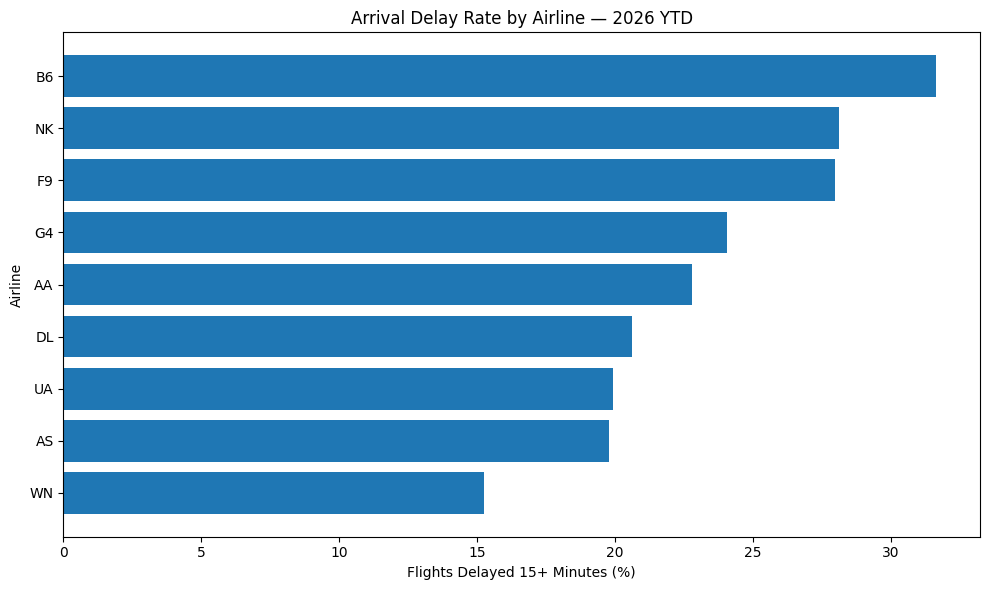

In [52]:
# Sort airlines by delay rate
delay_plot = airline_performance.sort_values("Delay_Rate", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    delay_plot["MKT_UNIQUE_CARRIER"],
    delay_plot["Delay_Rate"]
)

plt.title("Arrival Delay Rate by Airline — 2026 YTD")
plt.xlabel("Flights Delayed 15+ Minutes (%)")
plt.ylabel("Airline")

plt.tight_layout()
plt.show()

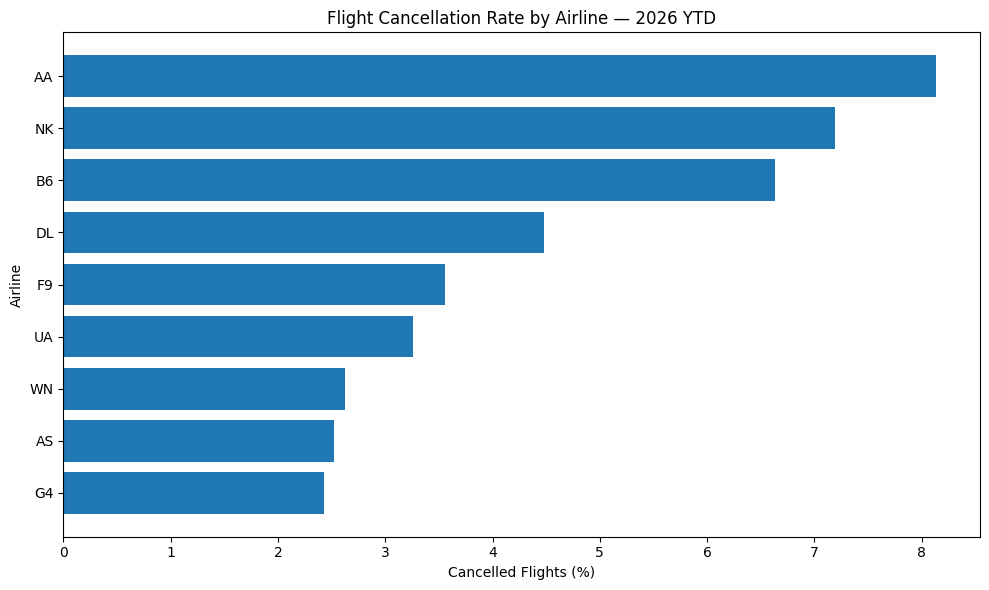

In [53]:
# Sort airlines by cancellation rate
cancel_plot = airline_performance.sort_values(
    "Cancellation_Rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    cancel_plot["MKT_UNIQUE_CARRIER"],
    cancel_plot["Cancellation_Rate"]
)

plt.title("Flight Cancellation Rate by Airline — 2026 YTD")
plt.xlabel("Cancelled Flights (%)")
plt.ylabel("Airline")

plt.tight_layout()
plt.show()

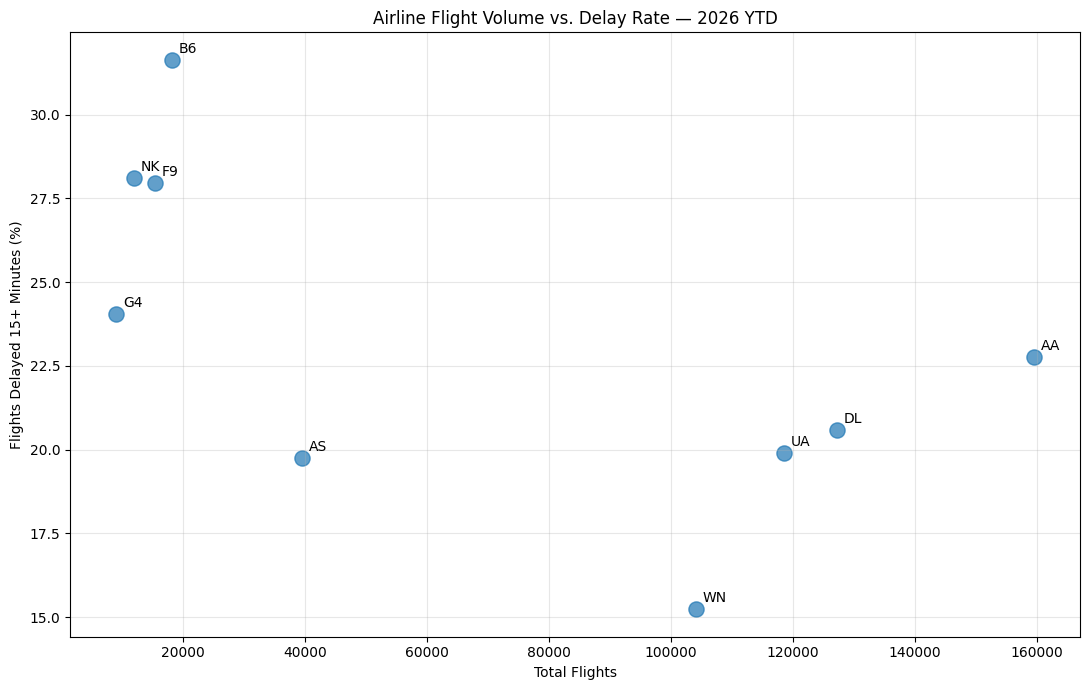

In [54]:
# Flight Volume vs Delay Performance

plt.figure(figsize=(11, 7))

plt.scatter(
    airline_performance["Total_Flights"],
    airline_performance["Delay_Rate"],
    s=120,
    alpha=0.7
)

# Add airline labels
for _, row in airline_performance.iterrows():
    plt.annotate(
        row["MKT_UNIQUE_CARRIER"],
        (row["Total_Flights"], row["Delay_Rate"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Airline Flight Volume vs. Delay Rate — 2026 YTD")
plt.xlabel("Total Flights")
plt.ylabel("Flights Delayed 15+ Minutes (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Airport Performance Analysis

This section examines flight performance across U.S. airports to identify locations with the highest rates of arrival delays. Airport-level analysis can help identify geographic patterns and operational bottlenecks that contribute to poor flight performance.

In [55]:
# Analyze delay performance by origin airport

airport_performance = (
    df.groupby("ORIGIN")
      .agg(
          Total_Flights=("ORIGIN", "size"),
          Average_Arrival_Delay=("ARR_DELAY", "mean"),
          Delay_Rate=("ARR_DEL15", "mean"),
          Cancelled_Flights=("CANCELLED", "sum")
      )
      .reset_index()
)

# Convert delay rate to percentage
airport_performance["Delay_Rate"] *= 100

# airports with at least 1,000 flights
major_airports = airport_performance[
    airport_performance["Total_Flights"] >= 1000
].copy()

# Show airports with highest delay rates
major_airports.sort_values(
    "Delay_Rate",
    ascending=False
).head(15)

,ORIGIN,Total_Flights,Average_Arrival_Delay,Delay_Rate,Cancelled_Flights
142,GRR,1609,26.027617,37.058446,51.0
100,DTW,10784,21.977510,35.666023,409.0
245,ORD,27221,19.256786,33.148283,1033.0
335,SYR,1154,19.682199,31.500466,76.0
158,HPN,1081,17.065130,30.360721,78.0
290,ROC,1218,18.364279,29.531388,85.0
123,FLL,8610,12.046321,28.904913,410.0
55,BUF,1781,15.146739,27.838164,121.0
20,ASE,1037,21.577046,27.736451,93.0
234,MSP,9619,10.813006,26.950959,223.0


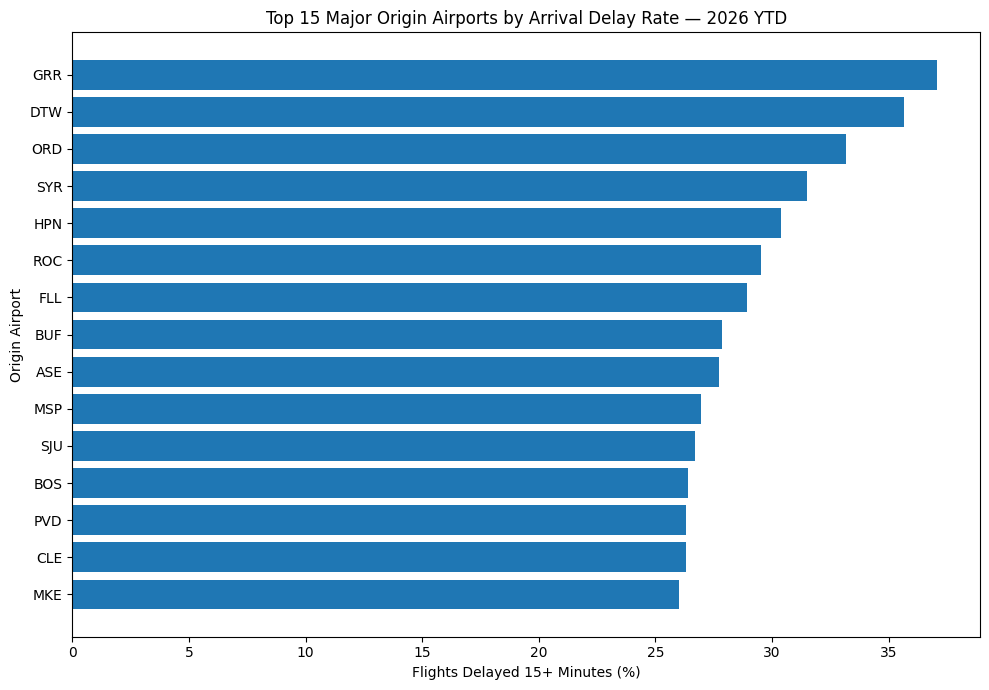

In [56]:
# Top 15 major airports by delay rate

airport_plot = (
    major_airports
    .sort_values("Delay_Rate", ascending=False)
    .head(15)
    .sort_values("Delay_Rate")
)

plt.figure(figsize=(10, 7))

plt.barh(
    airport_plot["ORIGIN"],
    airport_plot["Delay_Rate"]
)

plt.title("Top 15 Major Origin Airports by Arrival Delay Rate — 2026 YTD")
plt.xlabel("Flights Delayed 15+ Minutes (%)")
plt.ylabel("Origin Airport")

plt.tight_layout()
plt.show()

## Route Performance Analysis

This section examines route-level performance to identify heavily traveled origin-destination pairs with elevated delay rates. A minimum-flight threshold is used so that routes with very low traffic volumes do not disproportionately influence the comparison.

In [57]:
# Route-level performance analysis

route_performance = (
    flights.groupby("ROUTE")
    .agg(
        Total_Flights=("FL_DATE", "count"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean"),
        Delay_Rate=("ARR_DEL15", "mean"),
        Cancelled_Flights=("CANCELLED", "sum")
    )
    .reset_index()
)

route_performance["Delay_Rate"] *= 100

# Restrict to routes with at least 500 flights
major_routes = route_performance[
    route_performance["Total_Flights"] >= 500
].copy()

top_delayed_routes = (
    major_routes
    .sort_values("Delay_Rate", ascending=False)
    .head(15)
)

display(top_delayed_routes)

,ROUTE,Total_Flights,Avg_Arrival_Delay,Delay_Rate,Cancelled_Flights
218,ATL-MIA,547,17.719165,33.396584,17.0
181,ATL-FLL,676,15.522342,33.127889,27.0
4152,ORD-DCA,592,18.224638,31.340580,37.0
1721,DFW-ORD,501,22.747826,31.304348,41.0
4155,ORD-DFW,500,16.934641,31.154684,41.0
3468,MCO-SJU,506,16.771605,31.069959,20.0
4129,ORD-BOS,500,15.863248,30.982906,32.0
4206,ORD-MCO,540,13.815939,30.740038,13.0
681,BOS-ORD,500,12.526767,29.764454,31.0
2121,FLL-ATL,675,10.846154,29.384615,24.0


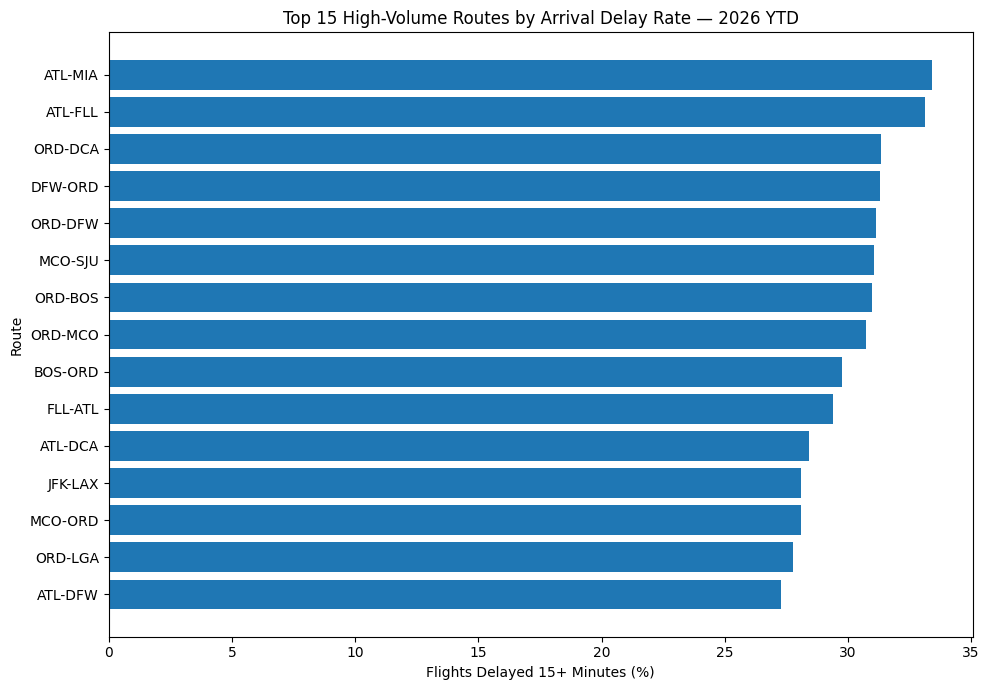

In [58]:
# Top 15 major routes by delay rate

route_plot = (
    top_delayed_routes
    .sort_values("Delay_Rate", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    route_plot["ROUTE"],
    route_plot["Delay_Rate"]
)

plt.title("Top 15 High-Volume Routes by Arrival Delay Rate — 2026 YTD")
plt.xlabel("Flights Delayed 15+ Minutes (%)")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

## Temporal Delay Analysis

This section evaluates how flight performance varies by time of day and day of week. Understanding temporal patterns can help identify periods when operational delays are more likely to occur.

In [59]:
# Delay performance by time of day

time_performance = (
    flights.groupby("TIME_OF_DAY")
    .agg(
        Total_Flights=("FL_DATE", "count"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean"),
        Delay_Rate=("ARR_DEL15", "mean"),
        Cancellation_Rate=("CANCELLED", "mean")
    )
    .reset_index()
)

time_performance["Delay_Rate"] *= 100
time_performance["Cancellation_Rate"] *= 100

time_order = [
    "Early Morning",
    "Morning",
    "Afternoon",
    "Evening",
    "Late Night"
]

time_performance["TIME_OF_DAY"] = pd.Categorical(
    time_performance["TIME_OF_DAY"],
    categories=time_order,
    ordered=True
)

time_performance = time_performance.sort_values("TIME_OF_DAY")

display(time_performance)

,TIME_OF_DAY,Total_Flights,Avg_Arrival_Delay,Delay_Rate,Cancellation_Rate
1,Early Morning,96997,0.492066,13.772259,5.074384
4,Morning,156398,3.661666,18.308903,4.677170
0,Afternoon,185431,8.556682,22.691655,4.432376
2,Evening,130554,10.463024,25.314225,5.052316
3,Late Night,33573,9.648298,23.335558,6.034611


In [60]:
# Delay performance by day of week

day_performance = (
    flights.groupby("DAY_NAME")
    .agg(
        Total_Flights=("FL_DATE", "count"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean"),
        Delay_Rate=("ARR_DEL15", "mean"),
        Cancellation_Rate=("CANCELLED", "mean")
    )
    .reset_index()
)

day_performance["Delay_Rate"] *= 100
day_performance["Cancellation_Rate"] *= 100

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_performance["DAY_NAME"] = pd.Categorical(
    day_performance["DAY_NAME"],
    categories=day_order,
    ordered=True
)

day_performance = day_performance.sort_values("DAY_NAME")

display(day_performance)

,DAY_NAME,Total_Flights,Avg_Arrival_Delay,Delay_Rate,Cancellation_Rate
1,Monday,82214,13.435302,24.911116,7.075437
5,Tuesday,72438,1.561619,16.027845,3.495403
6,Wednesday,73068,0.439616,15.249868,1.534187
4,Thursday,100211,3.553153,18.938541,0.547844
0,Friday,103243,6.038001,20.159964,1.460632
2,Saturday,89501,7.131998,22.415149,7.473660
3,Sunday,82278,13.779114,27.709100,13.201585


In [61]:
print("DATA COVERAGE")
print("-" * 40)

print("Earliest date:", flights["FL_DATE"].min())
print("Latest date:", flights["FL_DATE"].max())
print("Number of unique dates:", flights["FL_DATE"].nunique())

print("\nMONTHS INCLUDED:")
print(sorted(flights["MONTH"].unique()))

DATA COVERAGE
----------------------------------------
Earliest date: 2026-01-01 00:00:00
Latest date: 2026-01-31 00:00:00
Number of unique dates: 31

MONTHS INCLUDED:
[np.int64(1)]


## Expanded Dataset: Q1 2026

To expand the scope of the analysis beyond the initial January 2026 dataset, additional monthly flight records from February and March 2026 were incorporated to create a complete first-quarter (Q1) dataset. The expanded dataset provides a broader view of U.S. airline operations and allows performance patterns to be evaluated across multiple months rather than from a single-month snapshot.

Before integration, each monthly dataset was validated for file integrity and consistency. The January, February, and March datasets were verified before combination to reduce the risk of corrupted files, duplicate observations, or inconsistent data structures affecting the analysis. Following validation, the monthly records are standardized and combined into a single Q1 2026 analytical dataset.

The expanded dataset will be used to evaluate airline performance, airport operations, route reliability, arrival delays, and flight cancellations throughout Q1 2026. The larger multi-month dataset also provides a stronger foundation for exploratory data analysis, feature engineering, visualization, and predictive modeling aimed at identifying factors associated with flight delays.

In [1]:
# ============================================================
# BUILD CLEAN Q1 2026 MASTER DATASET
# LOW-MEMORY VERSION
# ============================================================

import pandas as pd
import zipfile
import glob
import os

# ------------------------------------------------------------
# 1. Define the fields we actually need
# ------------------------------------------------------------

target_columns = [
    "YEAR",
    "QUARTER",
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "FL_DATE",
    "MKT_UNIQUE_CARRIER",
    "MKT_CARRIER_FL_NUM",
    "ORIGIN",
    "ORIGIN_CITY_NAME",
    "ORIGIN_STATE_ABR",
    "DEST",
    "DEST_CITY_NAME",
    "DEST_STATE_ABR",
    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "CRS_ARR_TIME",
    "ARR_TIME",
    "ARR_DELAY",
    "ARR_DELAY_NEW",
    "ARR_DEL15",
    "CANCELLED",
    "CANCELLATION_CODE",
    "DIVERTED",
    "CRS_ELAPSED_TIME",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME",
    "FLIGHTS",
    "DISTANCE",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

# BTS pre-zipped names -> standardized names
rename_map = {
    "YEAR": "YEAR",
    "QUARTER": "QUARTER",
    "MONTH": "MONTH",
    "DAYOFMONTH": "DAY_OF_MONTH",
    "DAYOFWEEK": "DAY_OF_WEEK",
    "FLIGHTDATE": "FL_DATE",
    "MARKETING_AIRLINE_NETWORK": "MKT_UNIQUE_CARRIER",
    "FLIGHT_NUMBER_MARKETING_AIRLINE": "MKT_CARRIER_FL_NUM",
    "ORIGIN": "ORIGIN",
    "ORIGINCITYNAME": "ORIGIN_CITY_NAME",
    "ORIGINSTATE": "ORIGIN_STATE_ABR",
    "DEST": "DEST",
    "DESTCITYNAME": "DEST_CITY_NAME",
    "DESTSTATE": "DEST_STATE_ABR",
    "CRSDEPTIME": "CRS_DEP_TIME",
    "DEPTIME": "DEP_TIME",
    "DEPDELAY": "DEP_DELAY",
    "DEPDELAYMINUTES": "DEP_DELAY_NEW",
    "DEPDEL15": "DEP_DEL15",
    "CRSARRTIME": "CRS_ARR_TIME",
    "ARRTIME": "ARR_TIME",
    "ARRDELAY": "ARR_DELAY",
    "ARRDELAYMINUTES": "ARR_DELAY_NEW",
    "ARRDEL15": "ARR_DEL15",
    "CANCELLED": "CANCELLED",
    "CANCELLATIONCODE": "CANCELLATION_CODE",
    "DIVERTED": "DIVERTED",
    "CRSELAPSEDTIME": "CRS_ELAPSED_TIME",
    "ACTUALELAPSEDTIME": "ACTUAL_ELAPSED_TIME",
    "AIRTIME": "AIR_TIME",
    "FLIGHTS": "FLIGHTS",
    "DISTANCE": "DISTANCE",
    "CARRIERDELAY": "CARRIER_DELAY",
    "WEATHERDELAY": "WEATHER_DELAY",
    "NASDELAY": "NAS_DELAY",
    "SECURITYDELAY": "SECURITY_DELAY",
    "LATEAIRCRAFTDELAY": "LATE_AIRCRAFT_DELAY"
}

# ------------------------------------------------------------
# 2. Load January from the existing 41-column ZIP
# ------------------------------------------------------------

frames = []

jan_zip = glob.glob("/content/T_ONTIME_MARKETING*.zip")[0]

with zipfile.ZipFile(jan_zip, "r") as z:
    jan_csv = [x for x in z.namelist() if x.endswith(".csv")][0]

    with z.open(jan_csv) as f:
        jan = pd.read_csv(f, low_memory=False)

jan.columns = (
    jan.columns
    .str.strip()
    .str.upper()
)

# Keep only desired January columns that exist
jan = jan[
    [col for col in target_columns if col in jan.columns]
].copy()

frames.append(jan)

print(f"January loaded: {len(jan):,} rows")

# ------------------------------------------------------------
# 3. Load February + March from 120-column files
# ------------------------------------------------------------

for month_num in [2, 3]:

    zip_path = glob.glob(
        f"/content/*2026_{month_num}*.zip"
    )[0]

    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = [
            x for x in z.namelist()
            if x.endswith(".csv")
        ][0]

        # Read header only first
        with z.open(csv_name) as f:
            header = pd.read_csv(f, nrows=0)

        original_cols = header.columns.tolist()

        # Figure out which pre-zipped columns we need
        usecols = [
            col for col in original_cols
            if col.upper().replace("_", "") in rename_map
        ]

        with z.open(csv_name) as f:
            temp = pd.read_csv(
                f,
                usecols=usecols,
                low_memory=False
            )

    # Normalize the pre-zipped names
    temp.columns = [
        rename_map.get(
            col.upper().replace("_", ""),
            col
        )
        for col in temp.columns
    ]

    frames.append(temp)

    print(
        f"Month {month_num} loaded: "
        f"{len(temp):,} rows"
    )

# ------------------------------------------------------------
# 4. Combine Q1
# ------------------------------------------------------------

flights_q1 = pd.concat(
    frames,
    ignore_index=True,
    sort=False
)

# Parse date safely
flights_q1["FL_DATE"] = pd.to_datetime(
    flights_q1["FL_DATE"],
    errors="coerce"
)

# ------------------------------------------------------------
# 5. Create analytical features
# ------------------------------------------------------------

flights_q1["ROUTE"] = (
    flights_q1["ORIGIN"].astype(str)
    + "-"
    + flights_q1["DEST"].astype(str)
)

flights_q1["DEPARTURE_HOUR"] = (
    flights_q1["CRS_DEP_TIME"]
    .fillna(0)
    .astype(int) // 100
)

flights_q1.loc[
    flights_q1["DEPARTURE_HOUR"] == 24,
    "DEPARTURE_HOUR"
] = 0

def time_period(hour):
    if 5 <= hour < 9:
        return "Early Morning"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Late Night"

flights_q1["TIME_OF_DAY"] = (
    flights_q1["DEPARTURE_HOUR"]
    .apply(time_period)
)

flights_q1["DAY_NAME"] = (
    flights_q1["FL_DATE"].dt.day_name()
)

# ------------------------------------------------------------
# 6. Validate final dataset
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Q1 2026 MASTER DATASET")
print("=" * 60)

print(f"Rows: {len(flights_q1):,}")
print(f"Columns: {len(flights_q1.columns)}")

print("\nMonths included:")
print(sorted(flights_q1["MONTH"].dropna().unique()))

print("\nDate range:")
print(
    flights_q1["FL_DATE"].min(),
    "to",
    flights_q1["FL_DATE"].max()
)

print("\nFlights by month:")
print(
    flights_q1.groupby("MONTH")
    .size()
)

print("\nDuplicate rows:")
print(flights_q1.duplicated().sum())

January loaded: 602,953 rows
Month 2 loaded: 568,789 rows
Month 3 loaded: 675,500 rows


/tmp/ipykernel_32508/351137650.py:187: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights_q1["FL_DATE"] = pd.to_datetime(



Q1 2026 MASTER DATASET
Rows: 1,847,242
Columns: 41

Months included:
[np.int64(1), np.int64(2), np.int64(3)]

Date range:
2026-01-01 00:00:00 to 2026-03-31 00:00:00

Flights by month:
MONTH
1    602953
2    568789
3    675500
dtype: int64

Duplicate rows:
4


## Q1 2026 Flight Performance Overview

This section evaluates overall U.S. airline performance during the first quarter of 2026. Key performance indicators include total flight volume, arrival delay rate, average arrival delay, cancellation rate, and on-time performance. Monthly comparisons are also used to determine whether airline performance improved or declined between January and March.

In [3]:
# ============================================================
# Q1 2026 OVERALL PERFORMANCE KPIs
# ============================================================

total_flights = len(flights_q1)

cancelled_flights = flights_q1["CANCELLED"].sum()
cancellation_rate = flights_q1["CANCELLED"].mean() * 100

# Completed, non-cancelled flights
completed = flights_q1[flights_q1["CANCELLED"] == 0].copy()

delayed_flights = (completed["ARR_DEL15"] == 1).sum()
delay_rate = (completed["ARR_DEL15"] == 1).mean() * 100
on_time_rate = (completed["ARR_DEL15"] == 0).mean() * 100

avg_arrival_delay = completed["ARR_DELAY"].mean()

print("=" * 60)
print("Q1 2026 U.S. AIRLINE PERFORMANCE")
print("=" * 60)

print(f"Total scheduled flights: {total_flights:,}")
print(f"Completed flights: {len(completed):,}")
print(f"Cancelled flights: {int(cancelled_flights):,}")

print(f"\nCancellation rate: {cancellation_rate:.2f}%")
print(f"Arrival delay rate (15+ min): {delay_rate:.2f}%")
print(f"On-time arrival rate: {on_time_rate:.2f}%")
print(f"Average arrival delay: {avg_arrival_delay:.2f} minutes")

Q1 2026 U.S. AIRLINE PERFORMANCE
Total scheduled flights: 1,847,238
Completed flights: 1,784,932
Cancelled flights: 62,306

Cancellation rate: 3.37%
Arrival delay rate (15+ min): 21.54%
On-time arrival rate: 78.20%
Average arrival delay: 7.25 minutes


## Monthly Flight Performance Analysis

To identify changes in airline performance throughout the first quarter of 2026, flight operations were compared across January, February, and March. Monthly performance was evaluated using total scheduled flights, completed flights, cancellations, cancellation rate, arrival delay rate, on-time arrival rate, and average arrival delay. This comparison provides insight into whether operational performance remained consistent or changed throughout the quarter.

In [4]:
# ============================================================
# MONTHLY Q1 2026 PERFORMANCE
# ============================================================

monthly_results = []

month_names = {
    1: "January",
    2: "February",
    3: "March"
}

for month in [1, 2, 3]:

    month_data = flights_q1[
        flights_q1["MONTH"] == month
    ].copy()

    completed = month_data[
        month_data["CANCELLED"] == 0
    ].copy()

    total = len(month_data)
    completed_count = len(completed)
    cancelled = month_data["CANCELLED"].sum()

    cancellation_rate = (
        month_data["CANCELLED"].mean() * 100
    )

    delay_rate = (
        (completed["ARR_DEL15"] == 1).mean() * 100
    )

    on_time_rate = (
        (completed["ARR_DEL15"] == 0).mean() * 100
    )

    avg_delay = completed["ARR_DELAY"].mean()

    monthly_results.append({
        "Month": month_names[month],
        "Total_Flights": total,
        "Completed_Flights": completed_count,
        "Cancelled_Flights": int(cancelled),
        "Cancellation_Rate": cancellation_rate,
        "Delay_Rate": delay_rate,
        "On_Time_Rate": on_time_rate,
        "Avg_Arrival_Delay": avg_delay
    })

monthly_performance = pd.DataFrame(monthly_results)

# Format a display copy
display_table = monthly_performance.copy()

for col in [
    "Cancellation_Rate",
    "Delay_Rate",
    "On_Time_Rate",
    "Avg_Arrival_Delay"
]:
    display_table[col] = display_table[col].round(2)

display_table

,Month,Total_Flights,Completed_Flights,Cancelled_Flights,Cancellation_Rate,Delay_Rate,On_Time_Rate,Avg_Arrival_Delay
0,January,602953,573875,29078,4.82,20.68,79.10,6.46
1,February,568786,555441,13345,2.35,19.44,80.35,3.99
2,March,675499,655616,19883,2.94,24.06,75.58,10.72


### Monthly Performance Trends

Monthly comparisons show meaningful changes in airline operational performance during Q1 2026. February recorded the strongest overall performance, while March experienced a higher rate of delayed flights and a larger average arrival delay. January experienced the highest cancellation rate of the quarter. These differences suggest that airline operational performance varied considerably across the three-month period.

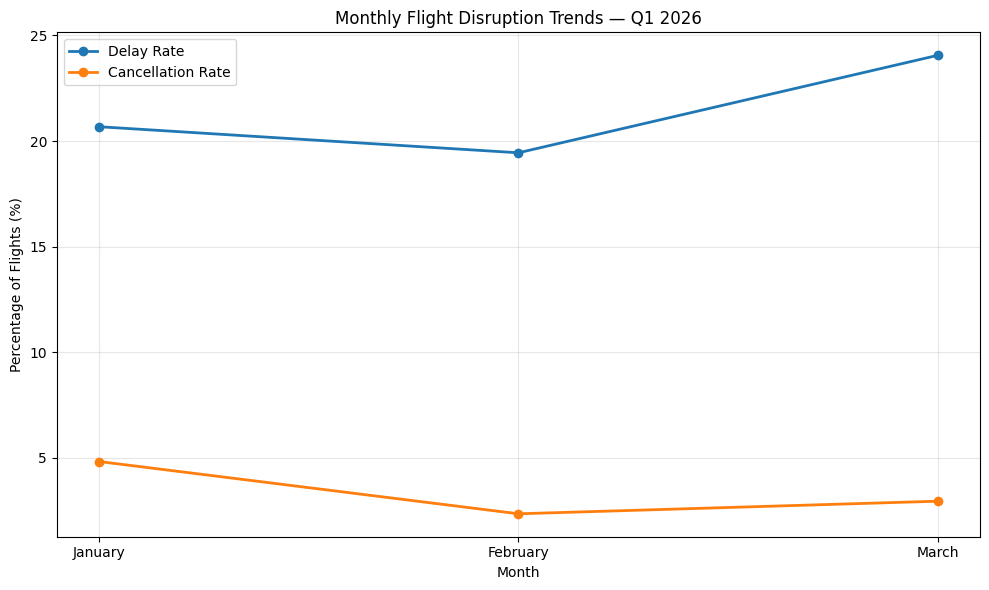

In [5]:
# ============================================================
# MONTHLY DELAY AND CANCELLATION TRENDS
# ============================================================

import matplotlib.pyplot as plt

months = monthly_performance["Month"]

plt.figure(figsize=(10, 6))

plt.plot(
    months,
    monthly_performance["Delay_Rate"],
    marker="o",
    linewidth=2,
    label="Delay Rate"
)

plt.plot(
    months,
    monthly_performance["Cancellation_Rate"],
    marker="o",
    linewidth=2,
    label="Cancellation Rate"
)

plt.title("Monthly Flight Disruption Trends — Q1 2026")
plt.xlabel("Month")
plt.ylabel("Percentage of Flights (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

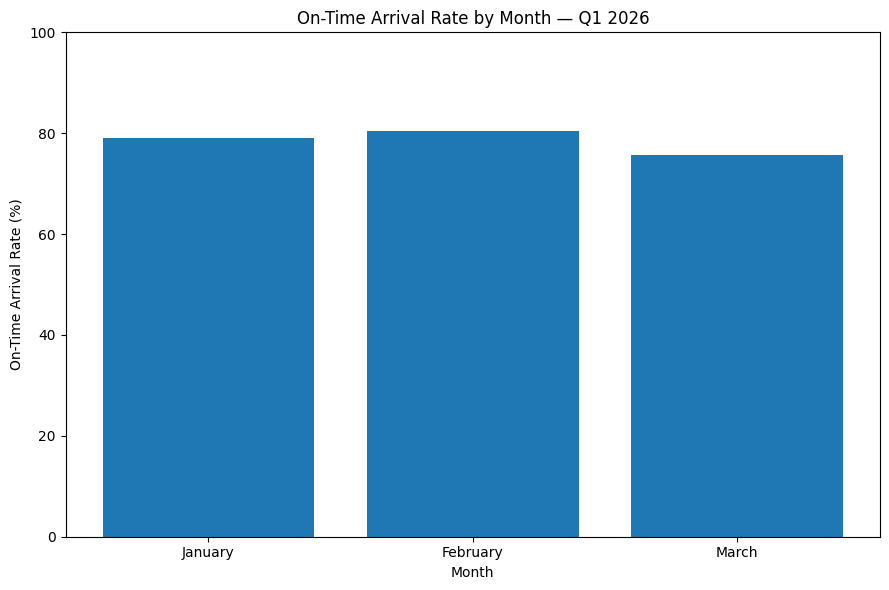

In [6]:
# ============================================================
# MONTHLY ON-TIME ARRIVAL PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    monthly_performance["Month"],
    monthly_performance["On_Time_Rate"]
)

plt.title("On-Time Arrival Rate by Month — Q1 2026")
plt.xlabel("Month")
plt.ylabel("On-Time Arrival Rate (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Airline Performance Analysis — Q1 2026

The following analysis compares the operational performance of U.S. airlines across the complete Q1 2026 dataset. Airline performance is evaluated using total flight volume, arrival delay rate, cancellation rate, on-time arrival rate, and average arrival delay. Examining these measures together provides a more complete assessment of airline reliability than relying on flight volume or a single performance measure alone.

In [12]:
# ============================================================
# FINAL Q1 2026 MASTER DATASET
# Correct airline schema before duplicate removal
# ============================================================

import pandas as pd
import zipfile
import glob
import re
import os

def canon(name):
    return re.sub(r"[^A-Z0-9]", "", str(name).upper())

# Standard names we want in the final dataset
aliases = {
    "YEAR": ["YEAR"],
    "QUARTER": ["QUARTER"],
    "MONTH": ["MONTH"],
    "DAY_OF_MONTH": ["DAYOFMONTH"],
    "DAY_OF_WEEK": ["DAYOFWEEK"],
    "FL_DATE": ["FLDATE", "FLIGHTDATE"],

    # IMPORTANT FIX:
    "MKT_UNIQUE_CARRIER": [
        "MKTUNIQUECARRIER",
        "IATACODEMARKETINGAIRLINE"
    ],

    "MKT_CARRIER_FL_NUM": [
        "MKTCARRIERFLNUM",
        "FLIGHTNUMBERMARKETINGAIRLINE"
    ],

    "ORIGIN": ["ORIGIN"],
    "ORIGIN_CITY_NAME": ["ORIGINCITYNAME"],
    "ORIGIN_STATE_ABR": ["ORIGINSTATEABR", "ORIGINSTATE"],

    "DEST": ["DEST"],
    "DEST_CITY_NAME": ["DESTCITYNAME"],
    "DEST_STATE_ABR": ["DESTSTATEABR", "DESTSTATE"],

    "CRS_DEP_TIME": ["CRSDEPTIME"],
    "DEP_TIME": ["DEPTIME"],
    "DEP_DELAY": ["DEPDELAY"],
    "DEP_DELAY_NEW": ["DEPDELAYNEW", "DEPDELAYMINUTES"],
    "DEP_DEL15": ["DEPDEL15"],

    "CRS_ARR_TIME": ["CRSARRTIME"],
    "ARR_TIME": ["ARRTIME"],
    "ARR_DELAY": ["ARRDELAY"],
    "ARR_DELAY_NEW": ["ARRDELAYNEW", "ARRDELAYMINUTES"],
    "ARR_DEL15": ["ARRDEL15"],

    "CANCELLED": ["CANCELLED"],
    "CANCELLATION_CODE": ["CANCELLATIONCODE"],
    "DIVERTED": ["DIVERTED"],

    "CRS_ELAPSED_TIME": ["CRSELAPSEDTIME"],
    "ACTUAL_ELAPSED_TIME": ["ACTUALELAPSEDTIME"],
    "AIR_TIME": ["AIRTIME"],
    "FLIGHTS": ["FLIGHTS"],
    "DISTANCE": ["DISTANCE"],

    "CARRIER_DELAY": ["CARRIERDELAY"],
    "WEATHER_DELAY": ["WEATHERDELAY"],
    "NAS_DELAY": ["NASDELAY"],
    "SECURITY_DELAY": ["SECURITYDELAY"],
    "LATE_AIRCRAFT_DELAY": ["LATEAIRCRAFTDELAY"]
}

q1_files = [
    glob.glob("/content/T_ONTIME_MARKETING*.zip")[0],
    glob.glob("/content/*2026_2*.zip")[0],
    glob.glob("/content/*2026_3*.zip")[0]
]

frames = []

for zip_path in q1_files:

    with zipfile.ZipFile(zip_path, "r") as z:

        csv_name = [
            x for x in z.namelist()
            if x.lower().endswith(".csv")
        ][0]

        # Read only header first
        with z.open(csv_name) as f:
            header = pd.read_csv(f, nrows=0)

        canonical_header = {
            canon(col): col
            for col in header.columns
        }

        selected = {}

        # Choose one source column for each final target column
        for target, possible_aliases in aliases.items():
            for alias in possible_aliases:
                if alias in canonical_header:
                    selected[target] = canonical_header[alias]
                    break

        usecols = list(selected.values())

        with z.open(csv_name) as f:
            temp = pd.read_csv(
                f,
                usecols=usecols,
                low_memory=False
            )

    # Rename source fields into common names
    reverse_map = {
        source: target
        for target, source in selected.items()
    }

    temp = temp.rename(columns=reverse_map)

    print(
        os.path.basename(zip_path),
        f"→ {len(temp):,} rows | "
        f"{len(temp.columns)} standardized columns"
    )

    print(
        "Airline values:",
        f"{temp['MKT_UNIQUE_CARRIER'].notna().sum():,}"
    )

    frames.append(temp)

# Combine January, February, March
flights_q1 = pd.concat(
    frames,
    ignore_index=True,
    sort=False
)

# Convert date
flights_q1["FL_DATE"] = pd.to_datetime(
    flights_q1["FL_DATE"],
    format="mixed",
    errors="coerce"
)

# NOW remove duplicates
before = len(flights_q1)

flights_q1 = (
    flights_q1
    .drop_duplicates()
    .copy()
)

removed = before - len(flights_q1)

# Create route
flights_q1["ROUTE"] = (
    flights_q1["ORIGIN"].astype(str)
    + "-"
    + flights_q1["DEST"].astype(str)
)

# Departure hour
flights_q1["DEPARTURE_HOUR"] = (
    flights_q1["CRS_DEP_TIME"]
    .fillna(0)
    .astype(int) // 100
)

flights_q1.loc[
    flights_q1["DEPARTURE_HOUR"] == 24,
    "DEPARTURE_HOUR"
] = 0

def time_period(hour):
    if 5 <= hour < 9:
        return "Early Morning"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Late Night"

flights_q1["TIME_OF_DAY"] = (
    flights_q1["DEPARTURE_HOUR"]
    .apply(time_period)
)

flights_q1["DAY_NAME"] = (
    flights_q1["FL_DATE"].dt.day_name()
)

# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL Q1 SCHEMA VALIDATION")
print("=" * 70)

validation = (
    flights_q1
    .groupby("MONTH")
    .agg(
        Rows=("MONTH", "size"),
        Airline_Values=("MKT_UNIQUE_CARRIER", "count"),
        Unique_Airlines=("MKT_UNIQUE_CARRIER", "nunique"),
        Origin_Values=("ORIGIN", "count"),
        Arrival_Delay_Values=("ARR_DELAY", "count"),
        Cancellation_Values=("CANCELLED", "count")
    )
)

display(validation)

print(f"\nTotal Q1 rows: {len(flights_q1):,}")
print(f"Exact duplicates removed: {removed:,}")
print(
    "Months:",
    sorted(flights_q1["MONTH"].dropna().unique())
)
print(
    "Date range:",
    flights_q1["FL_DATE"].min(),
    "to",
    flights_q1["FL_DATE"].max()
)

T_ONTIME_MARKETING_20260809_150731.zip → 602,953 rows | 34 standardized columns
Airline values: 602,953
On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2026_2.zip → 568,789 rows | 37 standardized columns
Airline values: 568,789
On_Time_Marketing_Carrier_On_Time_Performance_Beginning_January_2018_2026_3.zip → 675,500 rows | 37 standardized columns
Airline values: 675,500

FINAL Q1 SCHEMA VALIDATION


,Rows,Airline_Values,Unique_Airlines,Origin_Values,Arrival_Delay_Values,Cancellation_Values
MONTH,,,,,,
1,602953,602953,9,602953,572599,602953
2,568789,568789,9,568789,554297,568789
3,675500,675500,9,675500,653299,675500



Total Q1 rows: 1,847,242
Exact duplicates removed: 0
Months: [np.int64(1), np.int64(2), np.int64(3)]
Date range: 2026-01-01 00:00:00 to 2026-03-31 00:00:00


In [13]:
# ============================================================
# AIRLINE PERFORMANCE ANALYSIS — Q1 2026
# ============================================================

airline_q1 = (
    flights_q1
    .groupby("MKT_UNIQUE_CARRIER")
    .agg(
        Total_Flights=("MKT_UNIQUE_CARRIER", "size"),
        Cancelled_Flights=("CANCELLED", "sum"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean")
    )
    .reset_index()
)

airline_q1["Completed_Flights"] = (
    airline_q1["Total_Flights"] -
    airline_q1["Cancelled_Flights"]
)

airline_q1["Cancellation_Rate"] = (
    airline_q1["Cancelled_Flights"] /
    airline_q1["Total_Flights"] * 100
)

delay_rates = (
    flights_q1
    .groupby("MKT_UNIQUE_CARRIER")["ARR_DELAY"]
    .apply(lambda x: (x >= 15).sum() / x.notna().sum() * 100)
)

on_time_rates = (
    flights_q1
    .groupby("MKT_UNIQUE_CARRIER")["ARR_DELAY"]
    .apply(lambda x: (x < 15).sum() / x.notna().sum() * 100)
)

airline_q1["Delay_Rate"] = (
    airline_q1["MKT_UNIQUE_CARRIER"].map(delay_rates)
)

airline_q1["On_Time_Rate"] = (
    airline_q1["MKT_UNIQUE_CARRIER"].map(on_time_rates)
)

airline_q1["Cancelled_Flights"] = (
    airline_q1["Cancelled_Flights"].astype(int)
)

for col in [
    "Avg_Arrival_Delay",
    "Cancellation_Rate",
    "Delay_Rate",
    "On_Time_Rate"
]:
    airline_q1[col] = airline_q1[col].round(2)

airline_q1 = airline_q1.sort_values(
    "Delay_Rate",
    ascending=False
).reset_index(drop=True)

display(airline_q1)

print(
    "\nTotal flights represented:",
    f"{airline_q1['Total_Flights'].sum():,}"
)

,MKT_UNIQUE_CARRIER,Total_Flights,Cancelled_Flights,Avg_Arrival_Delay,Completed_Flights,Cancellation_Rate,Delay_Rate,On_Time_Rate
0,NK,36379,3123,19.66,33256.0,8.58,35.42,64.58
1,B6,57320,3010,15.63,54310.0,5.25,31.21,68.79
2,F9,50557,1405,13.01,49152.0,2.78,26.75,73.25
3,G4,30572,479,13.49,30093.0,1.57,24.93,75.07
4,AA,483902,22944,10.34,460958.0,4.74,23.04,76.96
5,DL,386832,14328,5.85,372504.0,3.70,20.13,79.87
6,WN,327083,5659,3.20,321424.0,1.73,20.07,79.93
7,UA,358108,9204,6.24,348904.0,2.57,19.80,80.20
8,AS,116489,2158,2.18,114331.0,1.85,18.58,81.42



Total flights represented: 1,847,242


### Airline Performance Findings

Airline performance varied considerably during Q1 2026. Spirit Airlines recorded the highest arrival delay rate and cancellation rate among the nine marketing carriers, while JetBlue also experienced a comparatively high delay rate. Alaska Airlines achieved the highest on-time arrival rate, followed closely by United Airlines and Southwest Airlines.

Flight volume alone did not appear to determine operational reliability. American Airlines operated the largest number of flights during the quarter, but its delay and cancellation rates remained higher than several other major carriers. These results suggest that operational performance differs meaningfully across airlines even after accounting for substantial differences in flight volume.

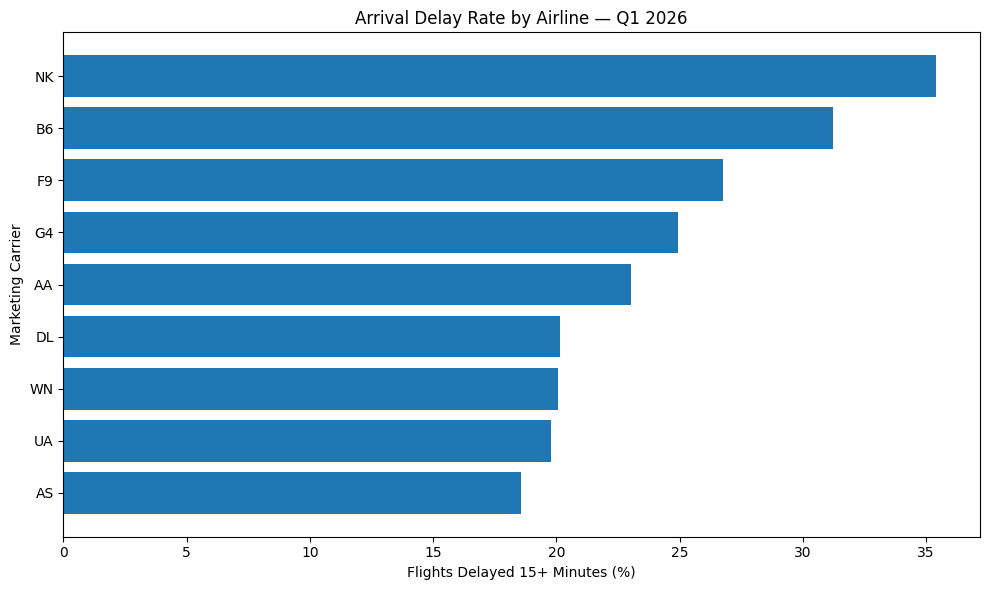

In [14]:
airline_plot = airline_q1.sort_values("Delay_Rate", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    airline_plot["MKT_UNIQUE_CARRIER"],
    airline_plot["Delay_Rate"]
)

plt.title("Arrival Delay Rate by Airline — Q1 2026")
plt.xlabel("Flights Delayed 15+ Minutes (%)")
plt.ylabel("Marketing Carrier")

plt.tight_layout()
plt.show()

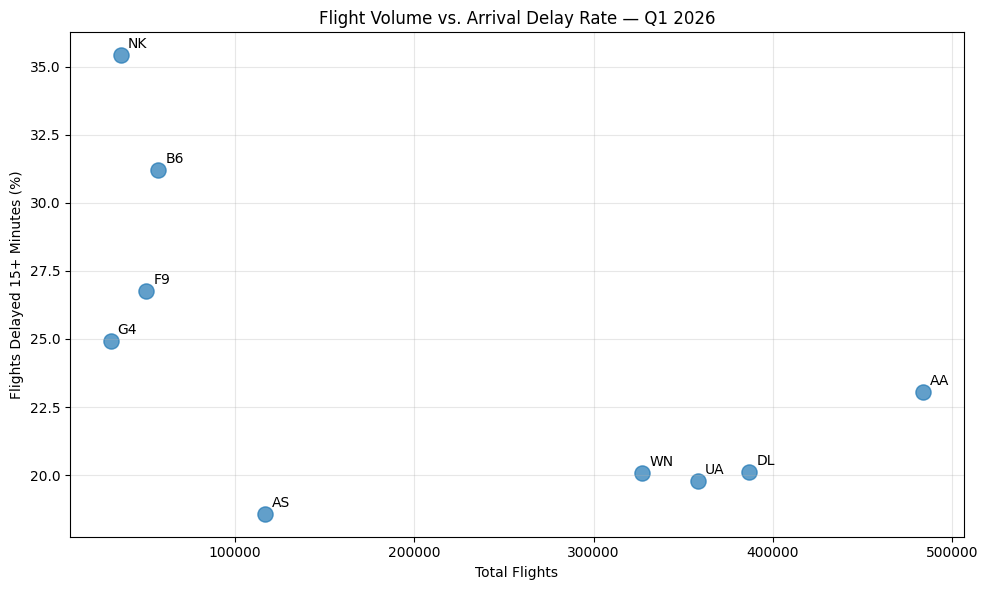

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    airline_q1["Total_Flights"],
    airline_q1["Delay_Rate"],
    s=120,
    alpha=0.7
)

for _, row in airline_q1.iterrows():
    plt.annotate(
        row["MKT_UNIQUE_CARRIER"],
        (row["Total_Flights"], row["Delay_Rate"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Flight Volume vs. Arrival Delay Rate — Q1 2026")
plt.xlabel("Total Flights")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Airport Performance Analysis

The next stage of the analysis evaluates flight performance across U.S. origin airports during Q1 2026. Airport-level performance is examined using total flight volume, average arrival delay, delay rate, and cancellation frequency. To prevent very small airports from disproportionately influencing the rankings, the analysis focuses on airports with a sufficient number of scheduled flights during the quarter.

This analysis helps identify airports where passengers were more likely to experience operational disruptions and allows airport performance to be compared independently of airline-level results.

In [16]:
# ============================================================
# AIRPORT PERFORMANCE ANALYSIS — Q1 2026
# ============================================================

airport_q1 = (
    flights_q1
    .groupby("ORIGIN")
    .agg(
        Total_Flights=("ORIGIN", "size"),
        Cancelled_Flights=("CANCELLED", "sum"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean")
    )
    .reset_index()
)

# Number of completed flights
airport_q1["Completed_Flights"] = (
    airport_q1["Total_Flights"] -
    airport_q1["Cancelled_Flights"]
)

# Cancellation rate
airport_q1["Cancellation_Rate"] = (
    airport_q1["Cancelled_Flights"] /
    airport_q1["Total_Flights"] * 100
)

# Delay rate: percentage of completed flights arriving 15+ minutes late
airport_delay_rates = (
    flights_q1
    .groupby("ORIGIN")["ARR_DELAY"]
    .apply(lambda x: (x >= 15).sum() / x.notna().sum() * 100)
)

airport_q1["Delay_Rate"] = (
    airport_q1["ORIGIN"].map(airport_delay_rates)
)

# On-time rate
airport_q1["On_Time_Rate"] = (
    100 - airport_q1["Delay_Rate"]
)

# Round values
for col in [
    "Avg_Arrival_Delay",
    "Cancellation_Rate",
    "Delay_Rate",
    "On_Time_Rate"
]:
    airport_q1[col] = airport_q1[col].round(2)

airport_q1["Cancelled_Flights"] = (
    airport_q1["Cancelled_Flights"].astype(int)
)

# ------------------------------------------------------------
# Focus on airports with at least 3,000 Q1 flights
# ------------------------------------------------------------

major_airports = airport_q1[
    airport_q1["Total_Flights"] >= 3000
].copy()

# Highest delay rates
top_delayed_airports = (
    major_airports
    .sort_values("Delay_Rate", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("TOP 15 AIRPORTS BY ARRIVAL DELAY RATE — Q1 2026")
print("=" * 60)

display(top_delayed_airports)

print("\nAirports analyzed:", len(airport_q1))
print(
    "Airports with at least 3,000 flights:",
    len(major_airports)
)

TOP 15 AIRPORTS BY ARRIVAL DELAY RATE — Q1 2026


,ORIGIN,Total_Flights,Cancelled_Flights,Avg_Arrival_Delay,Completed_Flights,Cancellation_Rate,Delay_Rate,On_Time_Rate
0,FLL,26789,1199,19.40,25590.0,4.48,34.29,65.71
1,ORD,88327,3269,17.84,85058.0,3.70,31.48,68.52
2,DTW,33323,1056,16.01,32267.0,3.17,29.50,70.50
3,ASE,3237,324,19.48,2913.0,10.01,28.91,71.09
4,GRR,5011,131,17.78,4880.0,2.61,28.82,71.18
5,SYR,3624,166,16.42,3458.0,4.58,28.77,71.23
6,DCA,36466,2275,13.11,34191.0,6.24,27.99,72.01
7,PBI,9466,431,14.37,9035.0,4.55,27.63,72.37
8,ROC,3824,186,14.68,3638.0,4.86,27.28,72.72
9,MCO,42632,1495,11.41,41137.0,3.51,27.17,72.83



Airports analyzed: 362
Airports with at least 3,000 flights: 97


### Airport Performance Findings

Airport performance varied substantially across Q1 2026. Fort Lauderdale (FLL) recorded the highest arrival delay rate among airports with at least 3,000 scheduled flights, while Chicago O’Hare (ORD) combined a high delay rate with one of the largest flight volumes in the analysis. Aspen (ASE) experienced the highest cancellation rate among the top delayed airports, indicating that airport disruption can appear through both delays and outright cancellations.

These results demonstrate why airport performance should be evaluated using multiple operational measures. A smaller airport may have a high disruption rate, while a major hub such as ORD can have a larger overall operational impact because of its much greater flight volume.

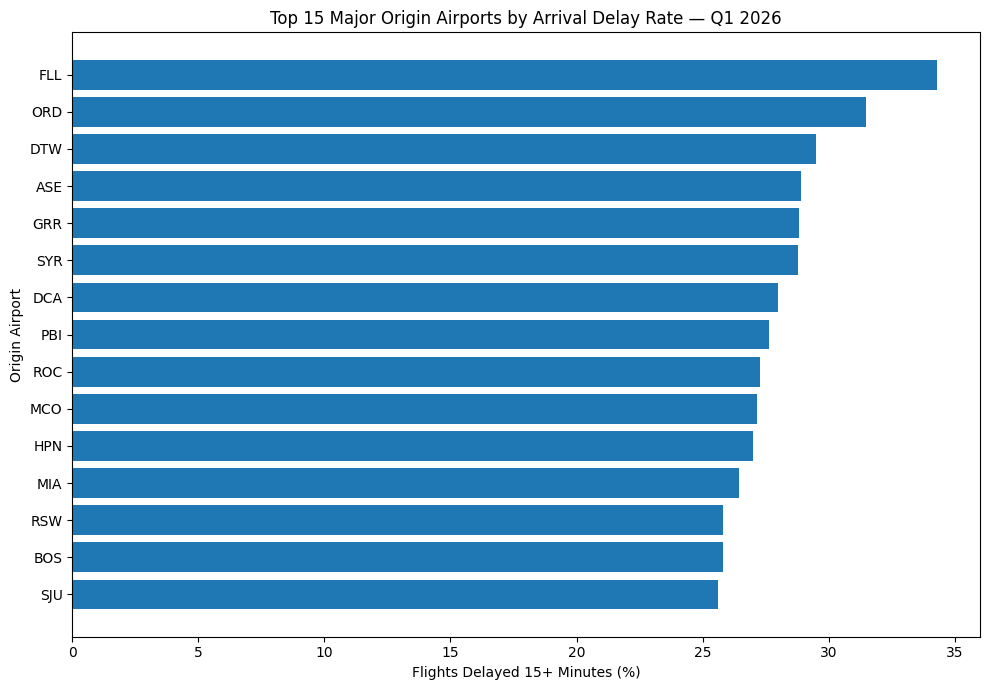

In [17]:
# Top 15 major airports by delay rate

airport_plot = (
    top_delayed_airports
    .sort_values("Delay_Rate", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    airport_plot["ORIGIN"],
    airport_plot["Delay_Rate"]
)

plt.title("Top 15 Major Origin Airports by Arrival Delay Rate — Q1 2026")
plt.xlabel("Flights Delayed 15+ Minutes (%)")
plt.ylabel("Origin Airport")

plt.tight_layout()
plt.show()

## Route Performance Analysis

The next stage of the analysis evaluates flight performance at the route level. Routes are defined as unique origin-destination airport combinations. Examining individual routes provides a more detailed view of operational performance than airline- or airport-level analysis alone.

To avoid emphasizing routes with very few scheduled flights, the analysis focuses on routes with sufficient flight volume during Q1 2026. Performance is evaluated using total flights, cancellation rates, arrival delay rates, on-time performance, and average arrival delay.

In [18]:
# ============================================================
# ROUTE ANALYSIS — COLUMN VALIDATION
# ============================================================

route_columns = [
    "ORIGIN",
    "DEST",
    "ARR_DELAY",
    "CANCELLED"
]

print("ROUTE ANALYSIS COLUMN CHECK")
print("=" * 50)

for col in route_columns:
    if col in flights_q1.columns:
        print(f"✅ {col}: available")
    else:
        print(f"❌ {col}: missing")

print("\nUnique origin airports:",
      flights_q1["ORIGIN"].nunique() if "ORIGIN" in flights_q1.columns else "N/A")

print("Unique destination airports:",
      flights_q1["DEST"].nunique() if "DEST" in flights_q1.columns else "N/A")

ROUTE ANALYSIS COLUMN CHECK
✅ ORIGIN: available
✅ DEST: available
✅ ARR_DELAY: available
✅ CANCELLED: available

Unique origin airports: 362
Unique destination airports: 362


In [19]:
# ============================================================
# ROUTE PERFORMANCE ANALYSIS — Q1 2026
# ============================================================

import pandas as pd
import numpy as np

# Work with only the columns needed for route analysis
route_data = flights_q1[
    ["ORIGIN", "DEST", "ARR_DELAY", "CANCELLED"]
].copy()

# Create route identifier
route_data["ROUTE"] = (
    route_data["ORIGIN"].astype(str)
    + " → "
    + route_data["DEST"].astype(str)
)

# Identify completed flights
route_data["COMPLETED"] = route_data["CANCELLED"].eq(0)

# Identify arrival delays of 15+ minutes
# Only completed flights with a valid arrival delay are evaluated
route_data["DELAYED_15"] = np.where(
    route_data["COMPLETED"] & route_data["ARR_DELAY"].notna(),
    route_data["ARR_DELAY"].ge(15),
    np.nan
)

# ------------------------------------------------------------
# Aggregate by route
# ------------------------------------------------------------

route_q1 = (
    route_data.groupby(["ROUTE", "ORIGIN", "DEST"])
    .agg(
        Total_Flights=("ROUTE", "size"),
        Cancelled_Flights=("CANCELLED", "sum"),
        Completed_Flights=("COMPLETED", "sum"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean"),
        Delay_Rate=("DELAYED_15", "mean")
    )
    .reset_index()
)

# Calculate percentages
route_q1["Cancellation_Rate"] = (
    route_q1["Cancelled_Flights"] /
    route_q1["Total_Flights"] * 100
)

route_q1["Delay_Rate"] = route_q1["Delay_Rate"] * 100

route_q1["On_Time_Rate"] = 100 - route_q1["Delay_Rate"]

# Round values
for col in [
    "Avg_Arrival_Delay",
    "Cancellation_Rate",
    "Delay_Rate",
    "On_Time_Rate"
]:
    route_q1[col] = route_q1[col].round(2)

# ------------------------------------------------------------
# Focus on higher-volume routes
# ------------------------------------------------------------

major_routes = route_q1[
    route_q1["Total_Flights"] >= 500
].copy()

# Rank by arrival delay rate
top_delayed_routes = (
    major_routes
    .sort_values("Delay_Rate", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("TOP 15 ROUTES BY ARRIVAL DELAY RATE — Q1 2026")
print("=" * 65)

display(
    top_delayed_routes[
        [
            "ROUTE",
            "Total_Flights",
            "Completed_Flights",
            "Cancelled_Flights",
            "Cancellation_Rate",
            "Delay_Rate",
            "On_Time_Rate",
            "Avg_Arrival_Delay"
        ]
    ]
)

print("\nTotal unique routes analyzed:", len(route_q1))
print("Routes with at least 500 flights:", len(major_routes))

TOP 15 ROUTES BY ARRIVAL DELAY RATE — Q1 2026


,ROUTE,Total_Flights,Completed_Flights,Cancelled_Flights,Cancellation_Rate,Delay_Rate,On_Time_Rate,Avg_Arrival_Delay
0,CVG → DCA,508,476,32.0,6.30,46.74,53.26,37.90
1,JFK → DCA,707,652,55.0,7.78,44.29,55.71,28.23
2,FLL → SJU,624,606,18.0,2.88,43.14,56.86,25.69
3,ORD → ASE,511,488,23.0,4.50,43.01,56.99,32.54
4,ORD → SBN,714,678,36.0,5.04,42.52,57.48,31.16
5,ORD → MKE,1233,1169,64.0,5.19,41.65,58.35,33.72
6,PHL → SJU,571,534,37.0,6.48,41.65,58.35,21.14
7,DTW → GRR,515,508,7.0,1.36,41.14,58.86,39.74
8,BOS → PBI,694,652,42.0,6.05,40.95,59.05,25.19
9,ORD → TYS,552,519,33.0,5.98,40.93,59.07,32.57



Total unique routes analyzed: 6422
Routes with at least 500 flights: 1120


## Route-Level Performance Analysis

To identify specific flight corridors associated with frequent disruptions, Q1 2026 flights were grouped by origin-destination route. Route performance was evaluated using flight volume, arrival delay rate, cancellation rate, on-time arrival rate, and average arrival delay. To reduce the influence of low-volume routes, comparisons were limited to routes with at least 500 scheduled flights during the quarter.

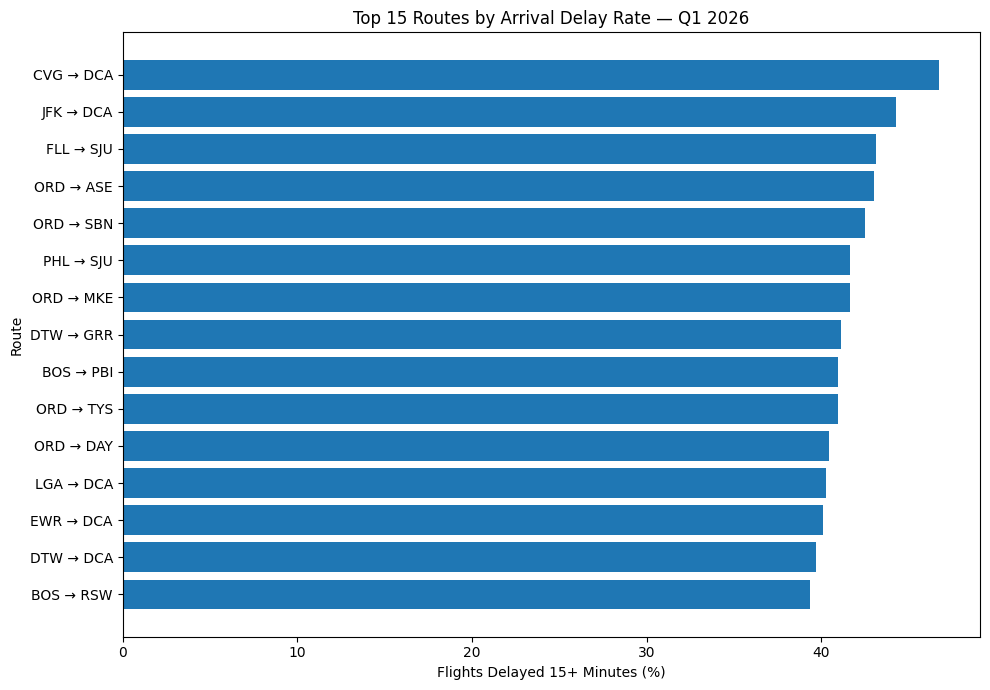

In [20]:
# ============================================================
# VISUALIZE TOP 15 ROUTES BY ARRIVAL DELAY RATE
# ============================================================

import matplotlib.pyplot as plt

# Sort so highest delay rate appears at top
route_plot = top_delayed_routes.sort_values(
    "Delay_Rate",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    route_plot["ROUTE"],
    route_plot["Delay_Rate"]
)

plt.title("Top 15 Routes by Arrival Delay Rate — Q1 2026")
plt.xlabel("Flights Delayed 15+ Minutes (%)")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

### Route Flight Volume and Delay Rate

To examine whether heavily traveled routes were associated with higher arrival delay rates, route-level flight volume was compared with the percentage of completed flights arriving at least 15 minutes late. This analysis helps distinguish high-delay routes from routes that experience disruptions primarily because they handle larger numbers of flights.

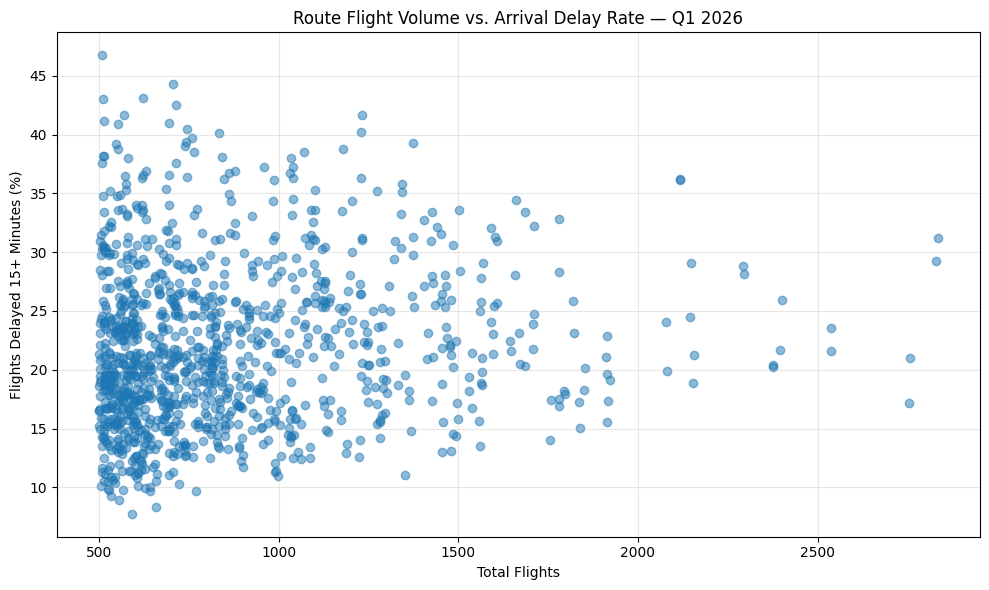

Correlation between route flight volume and delay rate: 0.124


In [21]:
# ============================================================
# ROUTE FLIGHT VOLUME VS. ARRIVAL DELAY RATE — Q1 2026
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    major_routes["Total_Flights"],
    major_routes["Delay_Rate"],
    alpha=0.5
)

plt.title("Route Flight Volume vs. Arrival Delay Rate — Q1 2026")
plt.xlabel("Total Flights")
plt.ylabel("Flights Delayed 15+ Minutes (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
route_correlation = major_routes[
    ["Total_Flights", "Delay_Rate"]
].corr().iloc[0, 1]

print(
    "Correlation between route flight volume and delay rate:",
    round(route_correlation, 3)
)

In [22]:
# ============================================================
# DAY-OF-WEEK ANALYSIS COLUMN CHECK
# ============================================================

possible_day_columns = [
    "DAY_OF_WEEK",
    "DayOfWeek",
    "DAYOFWEEK"
]

print("DAY-OF-WEEK COLUMN CHECK")
print("=" * 50)

for col in possible_day_columns:
    if col in flights_q1.columns:
        print(f"✅ {col}: available")
        print("Unique values:", sorted(flights_q1[col].dropna().unique()))

DAY-OF-WEEK COLUMN CHECK
✅ DAY_OF_WEEK: available
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


## Day-of-Week Performance Analysis

Flight performance was analyzed by day of the week to determine whether delays and cancellations varied systematically throughout Q1 2026. Each day was evaluated using total flight volume, cancellation rate, arrival delay rate, on-time arrival rate, and average arrival delay. This analysis helps identify whether certain days of the week were associated with greater operational disruption.

In [23]:
# ============================================================
# DAY-OF-WEEK PERFORMANCE ANALYSIS — Q1 2026
# ============================================================

import pandas as pd
import numpy as np

# Create working copy
day_data = flights_q1[
    ["DAY_OF_WEEK", "ARR_DELAY", "CANCELLED"]
].copy()

# Map BTS day numbers to names
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

day_data["Day"] = day_data["DAY_OF_WEEK"].map(day_names)

# Identify completed flights
day_data["COMPLETED"] = day_data["CANCELLED"].eq(0)

# Identify flights arriving 15+ minutes late
day_data["DELAYED_15"] = np.where(
    day_data["COMPLETED"] & day_data["ARR_DELAY"].notna(),
    day_data["ARR_DELAY"].ge(15),
    np.nan
)

# Aggregate performance by day
day_q1 = (
    day_data.groupby(["DAY_OF_WEEK", "Day"])
    .agg(
        Total_Flights=("DAY_OF_WEEK", "size"),
        Completed_Flights=("COMPLETED", "sum"),
        Cancelled_Flights=("CANCELLED", "sum"),
        Avg_Arrival_Delay=("ARR_DELAY", "mean"),
        Delay_Rate=("DELAYED_15", "mean")
    )
    .reset_index()
)

# Calculate rates
day_q1["Cancellation_Rate"] = (
    day_q1["Cancelled_Flights"] /
    day_q1["Total_Flights"] * 100
)

day_q1["Delay_Rate"] = day_q1["Delay_Rate"] * 100
day_q1["On_Time_Rate"] = 100 - day_q1["Delay_Rate"]

# Round results
for col in [
    "Avg_Arrival_Delay",
    "Cancellation_Rate",
    "Delay_Rate",
    "On_Time_Rate"
]:
    day_q1[col] = day_q1[col].round(2)

# Keep Monday-Sunday order
day_q1 = day_q1.sort_values("DAY_OF_WEEK")

print("DAY-OF-WEEK FLIGHT PERFORMANCE — Q1 2026")
print("=" * 65)

display(
    day_q1[
        [
            "Day",
            "Total_Flights",
            "Completed_Flights",
            "Cancelled_Flights",
            "Cancellation_Rate",
            "Delay_Rate",
            "On_Time_Rate",
            "Avg_Arrival_Delay"
        ]
    ]
)

DAY-OF-WEEK FLIGHT PERFORMANCE — Q1 2026


,Day,Total_Flights,Completed_Flights,Cancelled_Flights,Cancellation_Rate,Delay_Rate,On_Time_Rate,Avg_Arrival_Delay
0,Monday,279832,263170,16662.0,5.95,23.13,76.87,10.38
1,Tuesday,250644,243687,6957.0,2.78,17.64,82.36,3.23
2,Wednesday,233063,230214,2849.0,1.22,17.93,82.07,2.71
3,Thursday,278223,275951,2272.0,0.82,20.74,79.26,5.21
4,Friday,282049,277431,4618.0,1.64,23.11,76.89,9.53
5,Saturday,245173,235582,9591.0,3.91,22.49,77.51,7.46
6,Sunday,278258,258897,19361.0,6.96,25.49,74.51,11.47


### Day-of-Week Findings

Flight performance varied meaningfully across the week during Q1 2026. Sunday experienced the highest level of disruption, recording the highest arrival delay rate, cancellation rate, and average arrival delay, while also producing the lowest on-time arrival rate. Monday also showed elevated disruption compared with most midweek days.

Tuesday and Wednesday demonstrated the strongest overall performance. Both days recorded comparatively low delay rates and high on-time arrival rates, while Wednesday also produced a particularly low cancellation rate and average arrival delay. These results suggest that operational reliability was generally stronger during the middle of the week than at the beginning and end of the weekly travel cycle.

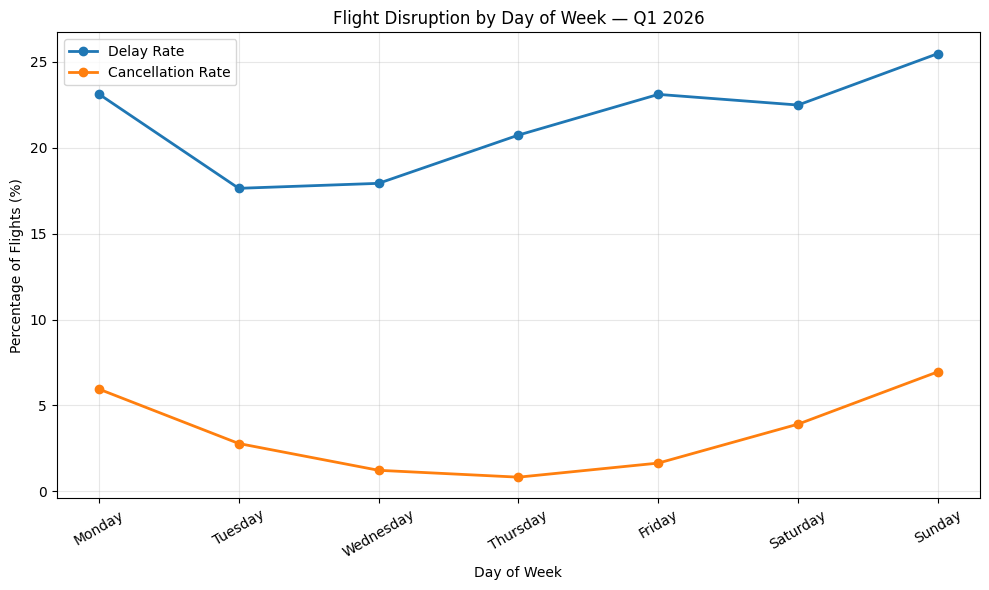

In [24]:
# ============================================================
# DAY-OF-WEEK DISRUPTION RATES — Q1 2026
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    day_q1["Day"],
    day_q1["Delay_Rate"],
    marker="o",
    linewidth=2,
    label="Delay Rate"
)

plt.plot(
    day_q1["Day"],
    day_q1["Cancellation_Rate"],
    marker="o",
    linewidth=2,
    label="Cancellation Rate"
)

plt.title("Flight Disruption by Day of Week — Q1 2026")
plt.xlabel("Day of Week")
plt.ylabel("Percentage of Flights (%)")

plt.xticks(rotation=30)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [25]:
# ============================================================
# TIME-OF-DAY COLUMN CHECK
# ============================================================

print("TIME-OF-DAY COLUMN CHECK")
print("-" * 50)

time_columns = [
    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "CRS_ARR_TIME",
    "ARR_TIME"
]

for col in time_columns:
    if col in flights_q1.columns:
        print(f"✅ {col}: available")
    else:
        print(f"❌ {col}: not available")

TIME-OF-DAY COLUMN CHECK
--------------------------------------------------
✅ CRS_DEP_TIME: available
✅ DEP_TIME: available
✅ DEP_DELAY: available
✅ DEP_DELAY_NEW: available
✅ DEP_DEL15: available
✅ CRS_ARR_TIME: available
✅ ARR_TIME: available


In [26]:
# ============================================================
# TIME-OF-DAY FLIGHT PERFORMANCE — Q1 2026
# ============================================================

import pandas as pd
import numpy as np

# Convert scheduled departure time to numeric
flights_q1["CRS_DEP_TIME"] = pd.to_numeric(
    flights_q1["CRS_DEP_TIME"],
    errors="coerce"
)

# Extract scheduled departure hour
flights_q1["DEP_HOUR"] = (
    flights_q1["CRS_DEP_TIME"] // 100
).astype("Int64")

# Handle 2400 as midnight
flights_q1.loc[
    flights_q1["DEP_HOUR"] == 24,
    "DEP_HOUR"
] = 0


# ------------------------------------------------------------
# Create time-of-day categories
# ------------------------------------------------------------

def categorize_time(hour):
    if pd.isna(hour):
        return np.nan
    elif 5 <= hour < 9:
        return "Early Morning"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Late Night"


flights_q1["TIME_OF_DAY"] = flights_q1["DEP_HOUR"].apply(
    categorize_time
)


# ------------------------------------------------------------
# Calculate performance
# ------------------------------------------------------------

time_order = [
    "Early Morning",
    "Morning",
    "Afternoon",
    "Evening",
    "Late Night"
]

results = []

for period in time_order:

    temp = flights_q1[
        flights_q1["TIME_OF_DAY"] == period
    ]

    total = len(temp)

    cancelled = (temp["CANCELLED"] == 1).sum()

    completed = total - cancelled

    completed_data = temp[
        temp["CANCELLED"] == 0
    ]

    delayed = (
        completed_data["ARR_DELAY"] >= 15
    ).sum()

    cancellation_rate = (
        cancelled / total * 100
        if total > 0 else np.nan
    )

    delay_rate = (
        delayed / completed * 100
        if completed > 0 else np.nan
    )

    on_time_rate = (
        100 - delay_rate
        if completed > 0 else np.nan
    )

    avg_delay = completed_data[
        "ARR_DELAY"
    ].mean()

    results.append({
        "Time_of_Day": period,
        "Total_Flights": total,
        "Completed_Flights": completed,
        "Cancelled_Flights": cancelled,
        "Cancellation_Rate": round(cancellation_rate, 2),
        "Delay_Rate": round(delay_rate, 2),
        "On_Time_Rate": round(on_time_rate, 2),
        "Avg_Arrival_Delay": round(avg_delay, 2)
    })


time_q1 = pd.DataFrame(results)

print("TIME-OF-DAY FLIGHT PERFORMANCE — Q1 2026")
display(time_q1)

print(
    "\nFlights represented:",
    time_q1["Total_Flights"].sum()
)

TIME-OF-DAY FLIGHT PERFORMANCE — Q1 2026


,Time_of_Day,Total_Flights,Completed_Flights,Cancelled_Flights,Cancellation_Rate,Delay_Rate,On_Time_Rate,Avg_Arrival_Delay
0,Early Morning,432874,418089,14785,3.42,13.60,86.40,-0.06
1,Morning,338740,328129,10611,3.13,18.72,81.28,4.10
2,Afternoon,553194,536133,17061,3.08,23.92,76.08,9.49
3,Evening,407716,392710,15006,3.68,28.02,71.98,13.42
4,Late Night,114718,109871,4847,4.23,25.36,74.64,11.55



Flights represented: 1847242


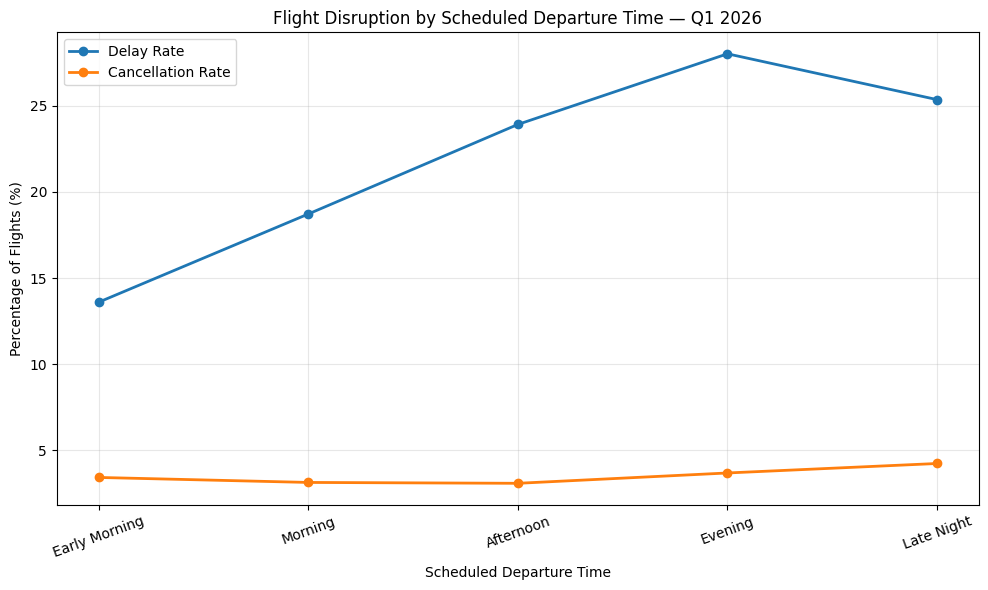

In [27]:
# ============================================================
# TIME-OF-DAY DELAY & CANCELLATION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    time_q1["Time_of_Day"],
    time_q1["Delay_Rate"],
    marker="o",
    linewidth=2,
    label="Delay Rate"
)

plt.plot(
    time_q1["Time_of_Day"],
    time_q1["Cancellation_Rate"],
    marker="o",
    linewidth=2,
    label="Cancellation Rate"
)

plt.title("Flight Disruption by Scheduled Departure Time — Q1 2026")
plt.xlabel("Scheduled Departure Time")
plt.ylabel("Percentage of Flights (%)")

plt.xticks(rotation=20)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

DEPARTURE VS. ARRIVAL DELAY ANALYSIS — Q1 2026
Flights analyzed: 1,780,195
Correlation between departure delay and arrival delay: 0.97
Average departure delay: 13.82 minutes
Average arrival delay: 7.25 minutes
Average difference (arrival - departure): -6.57 minutes


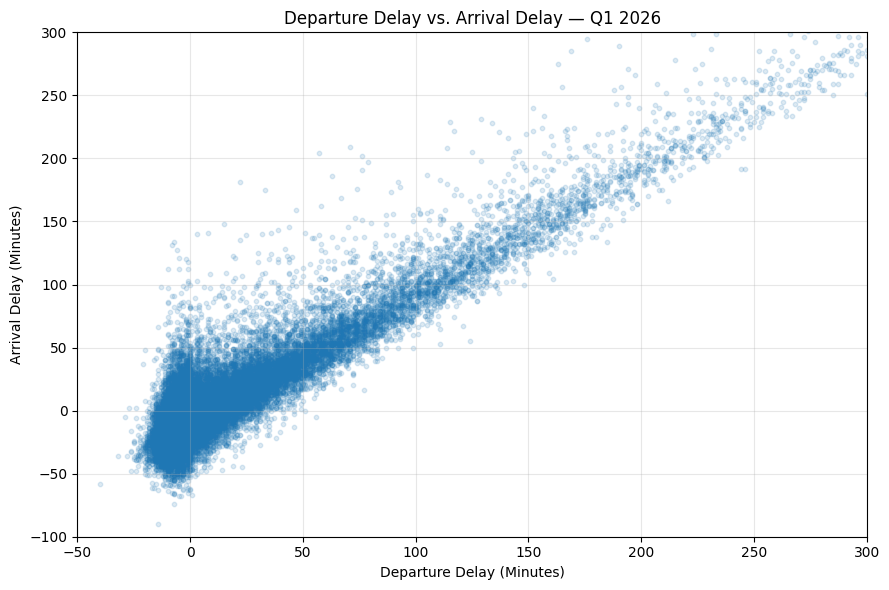

In [28]:
# ============================================================
# DEPARTURE DELAY VS. ARRIVAL DELAY — Q1 2026
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Keep completed flights with both delay measurements
delay_analysis = flights_q1[
    (flights_q1["CANCELLED"] == 0) &
    (flights_q1["DEP_DELAY"].notna()) &
    (flights_q1["ARR_DELAY"].notna())
][["DEP_DELAY", "ARR_DELAY"]].copy()

print("DEPARTURE VS. ARRIVAL DELAY ANALYSIS — Q1 2026")
print("=" * 60)

print(f"Flights analyzed: {len(delay_analysis):,}")

# Correlation
delay_correlation = delay_analysis[
    ["DEP_DELAY", "ARR_DELAY"]
].corr().iloc[0, 1]

print(
    "Correlation between departure delay and arrival delay:",
    round(delay_correlation, 3)
)

# Average delays
avg_dep = delay_analysis["DEP_DELAY"].mean()
avg_arr = delay_analysis["ARR_DELAY"].mean()

print(f"Average departure delay: {avg_dep:.2f} minutes")
print(f"Average arrival delay: {avg_arr:.2f} minutes")
print(
    f"Average difference (arrival - departure): "
    f"{avg_arr - avg_dep:.2f} minutes"
)

# ------------------------------------------------------------
# Scatterplot
# Use a sample so Colab doesn't struggle plotting ~1.8M points
# ------------------------------------------------------------

plot_sample = delay_analysis.sample(
    n=min(50000, len(delay_analysis)),
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    plot_sample["DEP_DELAY"],
    plot_sample["ARR_DELAY"],
    alpha=0.15,
    s=10
)

# Restrict display to a useful range so extreme outliers
# don't make the main pattern impossible to see
plt.xlim(-50, 300)
plt.ylim(-100, 300)

plt.title("Departure Delay vs. Arrival Delay — Q1 2026")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Arrival Delay (Minutes)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# DELAY CAUSE COLUMN CHECK
# ============================================================

delay_cause_columns = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

print("DELAY CAUSE COLUMN CHECK")
print("-" * 50)

for col in delay_cause_columns:
    if col in flights_q1.columns:
        print(f"✅ {col}: available")
    else:
        print(f"❌ {col}: not available")

DELAY CAUSE COLUMN CHECK
--------------------------------------------------
✅ CARRIER_DELAY: available
✅ WEATHER_DELAY: available
✅ NAS_DELAY: available
✅ SECURITY_DELAY: available
✅ LATE_AIRCRAFT_DELAY: available


In [30]:
# ============================================================
# DELAY CAUSE ANALYSIS — Q1 2026
# ============================================================

delay_causes = {
    "CARRIER_DELAY": "Carrier",
    "WEATHER_DELAY": "Weather",
    "NAS_DELAY": "National Airspace System",
    "SECURITY_DELAY": "Security",
    "LATE_AIRCRAFT_DELAY": "Late Aircraft"
}

# Calculate total delay minutes for each cause
cause_results = []

for column, name in delay_causes.items():
    total_minutes = flights_q1[column].fillna(0).sum()
    affected_flights = (flights_q1[column].fillna(0) > 0).sum()

    cause_results.append({
        "Delay_Cause": name,
        "Total_Delay_Minutes": total_minutes,
        "Flights_Affected": affected_flights
    })

cause_q1 = pd.DataFrame(cause_results)

# Calculate percentage of all cause-attributed delay minutes
total_delay_minutes = cause_q1["Total_Delay_Minutes"].sum()

cause_q1["Percent_of_Delay_Minutes"] = (
    cause_q1["Total_Delay_Minutes"] / total_delay_minutes * 100
).round(2)

cause_q1["Avg_Minutes_Per_Affected_Flight"] = (
    cause_q1["Total_Delay_Minutes"] /
    cause_q1["Flights_Affected"]
).round(2)

cause_q1["Total_Delay_Minutes"] = (
    cause_q1["Total_Delay_Minutes"].round(0).astype(int)
)

# Sort from largest to smallest
cause_q1 = cause_q1.sort_values(
    "Total_Delay_Minutes",
    ascending=False
).reset_index(drop=True)

print("DELAY CAUSE ANALYSIS — Q1 2026")
print("=" * 60)

display(cause_q1)

DELAY CAUSE ANALYSIS — Q1 2026


,Delay_Cause,Total_Delay_Minutes,Flights_Affected,Percent_of_Delay_Minutes,Avg_Minutes_Per_Affected_Flight
0,Late Aircraft,11252035,190254,38.51,59.14
1,Carrier,10301929,211165,35.25,48.79
2,National Airspace System,5573946,189738,19.07,29.38
3,Weather,2044108,25221,7.00,81.05
4,Security,50116,1605,0.17,31.22


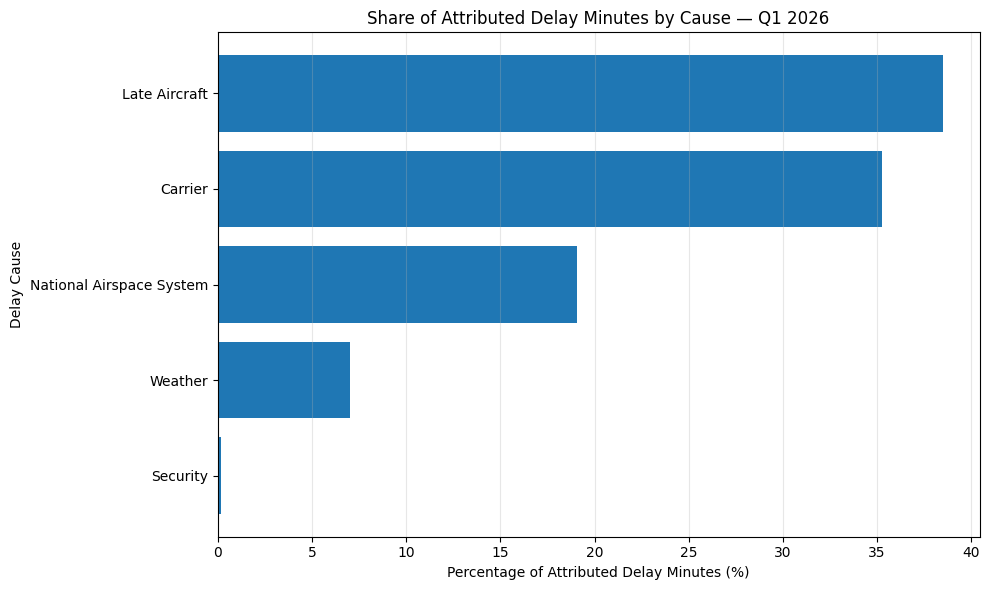

In [31]:
# ============================================================
# DELAY CAUSES VISUALIZATION — Q1 2026
# ============================================================

import matplotlib.pyplot as plt

plot_data = cause_q1.sort_values(
    "Percent_of_Delay_Minutes",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Delay_Cause"],
    plot_data["Percent_of_Delay_Minutes"]
)

plt.title("Share of Attributed Delay Minutes by Cause — Q1 2026")
plt.xlabel("Percentage of Attributed Delay Minutes (%)")
plt.ylabel("Delay Cause")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# PREDICTIVE MODELING — CREATE TARGET VARIABLE
# Q1 2026 U.S. AIRLINE FLIGHT PERFORMANCE
# ============================================================

import pandas as pd
import numpy as np

print("PREDICTIVE MODELING TARGET CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Keep completed flights with a known arrival delay
# ------------------------------------------------------------

model_df = flights_q1[
    (flights_q1["CANCELLED"] == 0) &
    (flights_q1["ARR_DELAY"].notna())
].copy()

# ------------------------------------------------------------
# 2. Create binary target
#
# 0 = arrived less than 15 minutes late
# 1 = arrived 15 or more minutes late
# ------------------------------------------------------------

model_df["ARRIVAL_DELAYED"] = (
    model_df["ARR_DELAY"] >= 15
).astype(int)

# ------------------------------------------------------------
# 3. Examine target distribution
# ------------------------------------------------------------

target_counts = model_df["ARRIVAL_DELAYED"].value_counts().sort_index()

target_percent = (
    model_df["ARRIVAL_DELAYED"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

target_summary = pd.DataFrame({
    "Flights": target_counts,
    "Percent": target_percent
})

target_summary.index = [
    "On Time (<15 min late)",
    "Delayed (15+ min)"
]

print(f"Total Q1 records: {len(flights_q1):,}")
print(f"Completed flights used for modeling: {len(model_df):,}")
print(f"Records excluded: {len(flights_q1) - len(model_df):,}")

print("\nTARGET DISTRIBUTION")
display(target_summary)

print("\nTarget values:", sorted(model_df["ARRIVAL_DELAYED"].unique()))

print(
    "\nArrival delay range:",
    round(model_df["ARR_DELAY"].min(), 2),
    "to",
    round(model_df["ARR_DELAY"].max(), 2),
    "minutes"
)

PREDICTIVE MODELING TARGET CHECK
Total Q1 records: 1,847,242
Completed flights used for modeling: 1,780,195
Records excluded: 67,047

TARGET DISTRIBUTION


,Flights,Percent
On Time (<15 min late),1395768,78.41
Delayed (15+ min),384427,21.59



Target values: [np.int64(0), np.int64(1)]

Arrival delay range: -90.0 to 10358.0 minutes


In [33]:
# ============================================================
# PREDICTIVE MODELING — FEATURE AVAILABILITY CHECK
# ============================================================

candidate_features = [
    # Calendar information
    "MONTH",
    "DAY_OF_WEEK",

    # Airline
    "MKT_UNIQUE_CARRIER",

    # Route
    "ORIGIN",
    "DEST",

    # Scheduled flight information
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE"
]

print("PREDICTOR AVAILABILITY CHECK")
print("=" * 60)

available_features = []
missing_features = []

for col in candidate_features:
    if col in model_df.columns:
        available_features.append(col)

        missing = model_df[col].isna().sum()
        missing_pct = (missing / len(model_df)) * 100

        print(
            f"✅ {col}: available | "
            f"Missing = {missing:,} ({missing_pct:.2f}%)"
        )
    else:
        missing_features.append(col)
        print(f"❌ {col}: not available")

print("\n" + "=" * 60)
print("Available predictors:", len(available_features))
print("Missing predictors:", len(missing_features))

print("\nAVAILABLE:")
print(available_features)

print("\nNOT AVAILABLE:")
print(missing_features)

PREDICTOR AVAILABILITY CHECK
✅ MONTH: available | Missing = 0 (0.00%)
✅ DAY_OF_WEEK: available | Missing = 0 (0.00%)
✅ MKT_UNIQUE_CARRIER: available | Missing = 0 (0.00%)
✅ ORIGIN: available | Missing = 0 (0.00%)
✅ DEST: available | Missing = 0 (0.00%)
✅ CRS_DEP_TIME: available | Missing = 0 (0.00%)
✅ CRS_ARR_TIME: available | Missing = 572,599 (32.16%)
✅ CRS_ELAPSED_TIME: available | Missing = 572,600 (32.17%)
✅ DISTANCE: available | Missing = 0 (0.00%)

Available predictors: 9
Missing predictors: 0

AVAILABLE:
['MONTH', 'DAY_OF_WEEK', 'MKT_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE']

NOT AVAILABLE:
[]


In [34]:
# ============================================================
# PREDICTIVE MODELING — PREPARE MODEL DATA
# ============================================================

model_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "MKT_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "CRS_DEP_TIME",
    "DISTANCE"
]

target = "ARRIVAL_DELAYED"

# Create modeling dataset
ml_df = model_df[model_features + [target]].copy()

print("MODELING DATASET CHECK")
print("=" * 60)

print(f"Rows: {len(ml_df):,}")
print(f"Predictors: {len(model_features)}")
print(f"Target: {target}")

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\nMISSING VALUES")
print("-" * 60)

missing_summary = pd.DataFrame({
    "Missing": ml_df.isna().sum(),
    "Percent": (ml_df.isna().mean() * 100).round(2)
})

display(missing_summary)

# ------------------------------------------------------------
# Check categorical variables
# ------------------------------------------------------------

print("\nCATEGORICAL FEATURE CHECK")
print("-" * 60)

for col in ["MKT_UNIQUE_CARRIER", "ORIGIN", "DEST"]:
    print(
        f"{col}: {ml_df[col].nunique():,} unique values"
    )

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\nTARGET DISTRIBUTION")
print("-" * 60)

print(
    ml_df[target]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages:")

print(
    (ml_df[target]
     .value_counts(normalize=True)
     .sort_index() * 100)
     .round(2)
)

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n" + "=" * 60)

if ml_df.isna().sum().sum() == 0:
    print("✅ Modeling dataset contains no missing values.")
else:
    print("⚠️ Missing values remain.")

print(f"Final modeling rows: {len(ml_df):,}")

MODELING DATASET CHECK
Rows: 1,780,195
Predictors: 7
Target: ARRIVAL_DELAYED

MISSING VALUES
------------------------------------------------------------


,Missing,Percent
MONTH,0,0.0
DAY_OF_WEEK,0,0.0
MKT_UNIQUE_CARRIER,0,0.0
ORIGIN,0,0.0
DEST,0,0.0
CRS_DEP_TIME,0,0.0
DISTANCE,0,0.0
ARRIVAL_DELAYED,0,0.0



CATEGORICAL FEATURE CHECK
------------------------------------------------------------
MKT_UNIQUE_CARRIER: 9 unique values
ORIGIN: 362 unique values
DEST: 362 unique values

TARGET DISTRIBUTION
------------------------------------------------------------
ARRIVAL_DELAYED
0    1395768
1     384427
Name: count, dtype: int64

Target percentages:
ARRIVAL_DELAYED
0    78.41
1    21.59
Name: proportion, dtype: float64

✅ Modeling dataset contains no missing values.
Final modeling rows: 1,780,195


In [35]:
# ============================================================
# PREDICTIVE MODELING — TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Separate predictors and target
X = ml_df[
    [
        "MONTH",
        "DAY_OF_WEEK",
        "MKT_UNIQUE_CARRIER",
        "ORIGIN",
        "DEST",
        "CRS_DEP_TIME",
        "DISTANCE"
    ]
].copy()

y = ml_df["ARRIVAL_DELAYED"].copy()

# ------------------------------------------------------------
# 80% training / 20% testing
# Stratify preserves target class proportions
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Validate split
# ------------------------------------------------------------

print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Full modeling dataset: {len(X):,}")
print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

print("\nTraining percentage:")
print(f"{len(X_train) / len(X) * 100:.2f}%")

print("\nTesting percentage:")
print(f"{len(X_test) / len(X) * 100:.2f}%")

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")

split_summary = pd.DataFrame({
    "Training": [
        (y_train == 0).sum(),
        (y_train == 1).sum()
    ],
    "Testing": [
        (y_test == 0).sum(),
        (y_test == 1).sum()
    ],
    "Training_Percent": [
        (y_train == 0).mean() * 100,
        (y_train == 1).mean() * 100
    ],
    "Testing_Percent": [
        (y_test == 0).mean() * 100,
        (y_test == 1).mean() * 100
    ]
}, index=[
    "On Time (<15 min)",
    "Delayed (15+ min)"
])

split_summary[
    ["Training_Percent", "Testing_Percent"]
] = split_summary[
    ["Training_Percent", "Testing_Percent"]
].round(2)

display(split_summary)

# Final checks
print("\n" + "=" * 60)

print(
    "Training + Testing =",
    f"{len(X_train) + len(X_test):,}"
)

print(
    "Original dataset =",
    f"{len(X):,}"
)

if len(X_train) + len(X_test) == len(X):
    print("✅ All modeling records accounted for.")
else:
    print("❌ Split size mismatch.")

TRAIN / TEST SPLIT
Full modeling dataset: 1,780,195
Training observations: 1,424,156
Testing observations: 356,039

Training percentage:
80.00%

Testing percentage:
20.00%

TARGET DISTRIBUTION


,Training,Testing,Training_Percent,Testing_Percent
On Time (<15 min),1116614,279154,78.41,78.41
Delayed (15+ min),307542,76885,21.59,21.59



Training + Testing = 1,780,195
Original dataset = 1,780,195
✅ All modeling records accounted for.


In [36]:
# ============================================================
# PREDICTIVE MODELING — PREPROCESSING / ONE-HOT ENCODING
# ============================================================

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

print("PREPROCESSING MODEL FEATURES")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create scheduled departure hour
# ------------------------------------------------------------

X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

X_train_prep["DEP_HOUR"] = (
    pd.to_numeric(X_train_prep["CRS_DEP_TIME"], errors="coerce") // 100
).astype("int16")

X_test_prep["DEP_HOUR"] = (
    pd.to_numeric(X_test_prep["CRS_DEP_TIME"], errors="coerce") // 100
).astype("int16")

# Handle 2400 as midnight
X_train_prep.loc[
    X_train_prep["DEP_HOUR"] == 24, "DEP_HOUR"
] = 0

X_test_prep.loc[
    X_test_prep["DEP_HOUR"] == 24, "DEP_HOUR"
] = 0

# We no longer need raw HHMM departure time
X_train_prep = X_train_prep.drop(columns=["CRS_DEP_TIME"])
X_test_prep = X_test_prep.drop(columns=["CRS_DEP_TIME"])


# ------------------------------------------------------------
# 2. Define categorical and numeric predictors
# ------------------------------------------------------------

categorical_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "MKT_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_HOUR"
]

numeric_features = [
    "DISTANCE"
]


# ------------------------------------------------------------
# 3. Create sparse one-hot encoder
# ------------------------------------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype="float32"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_features),
        ("numeric", "passthrough", numeric_features)
    ],
    sparse_threshold=1.0
)


# ------------------------------------------------------------
# 4. Fit ONLY on training data
# ------------------------------------------------------------

X_train_encoded = preprocessor.fit_transform(X_train_prep)

# Apply same transformation to test data
X_test_encoded = preprocessor.transform(X_test_prep)


# ------------------------------------------------------------
# 5. Validate results
# ------------------------------------------------------------

print(f"Training rows: {X_train_encoded.shape[0]:,}")
print(f"Testing rows: {X_test_encoded.shape[0]:,}")

print(
    f"Encoded predictor columns: "
    f"{X_train_encoded.shape[1]:,}"
)

print("\nMatrix types:")
print("Training:", type(X_train_encoded))
print("Testing:", type(X_test_encoded))

print("\nMatrix shapes:")
print("Training:", X_train_encoded.shape)
print("Testing:", X_test_encoded.shape)

print("\nDeparture hour range:")
print(
    X_train_prep["DEP_HOUR"].min(),
    "to",
    X_train_prep["DEP_HOUR"].max()
)

print("\n" + "=" * 60)

if (
    X_train_encoded.shape[0] == len(y_train)
    and X_test_encoded.shape[0] == len(y_test)
):
    print("✅ Preprocessing completed successfully.")
else:
    print("❌ Row mismatch detected.")

PREPROCESSING MODEL FEATURES
Training rows: 1,424,156
Testing rows: 356,039
Encoded predictor columns: 768

Matrix types:
Training: <class 'scipy.sparse._csr.csr_matrix'>
Testing: <class 'scipy.sparse._csr.csr_matrix'>

Matrix shapes:
Training: (1424156, 768)
Testing: (356039, 768)

Departure hour range:
0 to 23

✅ Preprocessing completed successfully.


In [40]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("TRAINING LOGISTIC REGRESSION MODEL")
print("=" * 60)

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=300,
    solver="liblinear",
    random_state=42
)

log_model.fit(X_train_encoded, y_train)

print("✅ Model training complete.")

# Predictions
log_predictions = log_model.predict(X_test_encoded)
log_probabilities = log_model.predict_proba(X_test_encoded)[:, 1]

# Metrics
log_accuracy = accuracy_score(y_test, log_predictions)
log_precision = precision_score(y_test, log_predictions)
log_recall = recall_score(y_test, log_predictions)
log_f1 = f1_score(y_test, log_predictions)
log_auc = roc_auc_score(y_test, log_probabilities)

print("\nLOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy:  {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall:    {log_recall:.4f}")
print(f"F1 Score:  {log_f1:.4f}")
print(f"ROC-AUC:   {log_auc:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 60)
print(confusion_matrix(y_test, log_predictions))

print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        log_predictions,
        target_names=["On Time", "Delayed"]
    )
)

TRAINING LOGISTIC REGRESSION MODEL
✅ Model training complete.

LOGISTIC REGRESSION RESULTS
Accuracy:  0.6004
Precision: 0.2966
Recall:    0.6204
F1 Score:  0.4013
ROC-AUC:   0.6482

CONFUSION MATRIX
------------------------------------------------------------
[[166057 113097]
 [ 29189  47696]]

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

     On Time       0.85      0.59      0.70    279154
     Delayed       0.30      0.62      0.40     76885

    accuracy                           0.60    356039
   macro avg       0.57      0.61      0.55    356039
weighted avg       0.73      0.60      0.64    356039



In [41]:
# ============================================================
# MODEL 2 — DECISION TREE
# Q1 2026 ARRIVAL DELAY PREDICTION
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("TRAINING DECISION TREE MODEL")
print("=" * 60)

# Create model
tree_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)

# Train model
tree_model.fit(
    X_train_encoded,
    y_train
)

print("✅ Model training complete.")

# Predictions
tree_predictions = tree_model.predict(
    X_test_encoded
)

tree_probabilities = tree_model.predict_proba(
    X_test_encoded
)[:, 1]

# Evaluation metrics
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_precision = precision_score(
    y_test,
    tree_predictions
)

tree_recall = recall_score(
    y_test,
    tree_predictions
)

tree_f1 = f1_score(
    y_test,
    tree_predictions
)

tree_auc = roc_auc_score(
    y_test,
    tree_probabilities
)

print("\nDECISION TREE RESULTS")
print("=" * 60)

print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"F1 Score:  {tree_f1:.4f}")
print(f"ROC-AUC:   {tree_auc:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 60)

print(
    confusion_matrix(
        y_test,
        tree_predictions
    )
)

print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        tree_predictions,
        target_names=[
            "On Time",
            "Delayed"
        ]
    )
)

TRAINING DECISION TREE MODEL
✅ Model training complete.

DECISION TREE RESULTS
Accuracy:  0.6292
Precision: 0.2927
Recall:    0.5063
F1 Score:  0.3710
ROC-AUC:   0.6263

CONFUSION MATRIX
------------------------------------------------------------
[[185106  94048]
 [ 37956  38929]]

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

     On Time       0.83      0.66      0.74    279154
     Delayed       0.29      0.51      0.37     76885

    accuracy                           0.63    356039
   macro avg       0.56      0.58      0.55    356039
weighted avg       0.71      0.63      0.66    356039



In [42]:
# ============================================================
# MODEL 3 — RANDOM FOREST
# Q1 2026 ARRIVAL DELAY PREDICTION
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("TRAINING RANDOM FOREST MODEL")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(
    X_train_encoded,
    y_train
)

print("✅ Model training complete.")

# Predictions
rf_predictions = rf_model.predict(
    X_test_encoded
)

rf_probabilities = rf_model.predict_proba(
    X_test_encoded
)[:, 1]

# Metrics
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("\nRANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 60)

print(
    confusion_matrix(
        y_test,
        rf_predictions
    )
)

print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "On Time",
            "Delayed"
        ]
    )
)

TRAINING RANDOM FOREST MODEL
✅ Model training complete.

RANDOM FOREST RESULTS
Accuracy:  0.6035
Precision: 0.2980
Recall:    0.6170
F1 Score:  0.4019
ROC-AUC:   0.6523

CONFUSION MATRIX
------------------------------------------------------------
[[167423 111731]
 [ 29444  47441]]

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

     On Time       0.85      0.60      0.70    279154
     Delayed       0.30      0.62      0.40     76885

    accuracy                           0.60    356039
   macro avg       0.57      0.61      0.55    356039
weighted avg       0.73      0.60      0.64    356039



In [43]:
# ============================================================
# MODEL COMPARISON — Q1 2026
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        tree_recall,
        rf_recall
    ],
    "F1_Score": [
        log_f1,
        tree_f1,
        rf_f1
    ],
    "ROC_AUC": [
        log_auc,
        tree_auc,
        rf_auc
    ]
})

# Convert metrics to rounded display values
display_comparison = model_comparison.copy()

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]:
    display_comparison[col] = (
        display_comparison[col]
        .round(4)
    )

print("MODEL PERFORMANCE COMPARISON — Q1 2026")
print("=" * 70)

display(display_comparison)

# Identify best model by selected metrics
print("\nBEST MODEL BY METRIC")
print("=" * 70)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]:
    best_index = model_comparison[metric].idxmax()

    print(
        f"{metric}: "
        f"{model_comparison.loc[best_index, 'Model']} "
        f"({model_comparison.loc[best_index, metric]:.4f})"
    )

MODEL PERFORMANCE COMPARISON — Q1 2026


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.6004,0.2966,0.6204,0.4013,0.6482
1,Decision Tree,0.6292,0.2927,0.5063,0.3710,0.6263
2,Random Forest,0.6035,0.2980,0.6170,0.4019,0.6523



BEST MODEL BY METRIC
Accuracy: Decision Tree (0.6292)
Precision: Random Forest (0.2980)
Recall: Logistic Regression (0.6204)
F1_Score: Random Forest (0.4019)
ROC_AUC: Random Forest (0.6523)


In [44]:
# ============================================================
# MODEL 4 — HISTOGRAM GRADIENT BOOSTING
# Q1 2026 ARRIVAL DELAY PREDICTION
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import numpy as np

print("TRAINING GRADIENT BOOSTING MODEL")
print("=" * 60)

# ------------------------------------------------------------
# 1. Prepare copies of original train/test data
# ------------------------------------------------------------

X_train_gb = X_train.copy()
X_test_gb = X_test.copy()

# Convert scheduled departure time to hour
X_train_gb["DEP_HOUR"] = (
    X_train_gb["CRS_DEP_TIME"].astype(float) // 100
).astype(int)

X_test_gb["DEP_HOUR"] = (
    X_test_gb["CRS_DEP_TIME"].astype(float) // 100
).astype(int)

# Convert 2400 to midnight
X_train_gb.loc[X_train_gb["DEP_HOUR"] == 24, "DEP_HOUR"] = 0
X_test_gb.loc[X_test_gb["DEP_HOUR"] == 24, "DEP_HOUR"] = 0

# Remove raw HHMM time
X_train_gb.drop(columns=["CRS_DEP_TIME"], inplace=True)
X_test_gb.drop(columns=["CRS_DEP_TIME"], inplace=True)

# ------------------------------------------------------------
# 2. Encode text categories
# ------------------------------------------------------------

categorical_cols = [
    "MKT_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST"
]

ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_gb[categorical_cols] = ordinal_encoder.fit_transform(
    X_train_gb[categorical_cols]
)

X_test_gb[categorical_cols] = ordinal_encoder.transform(
    X_test_gb[categorical_cols]
)

# Convert everything to float32 to reduce RAM usage
X_train_gb = X_train_gb.astype("float32")
X_test_gb = X_test_gb.astype("float32")

# ------------------------------------------------------------
# 3. Calculate balanced sample weights
# ------------------------------------------------------------

from sklearn.utils.class_weight import compute_sample_weight

gb_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# ------------------------------------------------------------
# 4. Create and train model
# ------------------------------------------------------------

gb_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=150,
    max_leaf_nodes=31,
    min_samples_leaf=100,
    random_state=42
)

gb_model.fit(
    X_train_gb,
    y_train,
    sample_weight=gb_weights
)

print("✅ Model training complete.")

# ------------------------------------------------------------
# 5. Predictions
# ------------------------------------------------------------

gb_predictions = gb_model.predict(X_test_gb)
gb_probabilities = gb_model.predict_proba(X_test_gb)[:, 1]

# ------------------------------------------------------------
# 6. Metrics
# ------------------------------------------------------------

gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_precision = precision_score(y_test, gb_predictions)
gb_recall = recall_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions)
gb_auc = roc_auc_score(y_test, gb_probabilities)

print("\nGRADIENT BOOSTING RESULTS")
print("=" * 60)

print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"F1 Score:  {gb_f1:.4f}")
print(f"ROC-AUC:   {gb_auc:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 60)
print(confusion_matrix(y_test, gb_predictions))

print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        gb_predictions,
        target_names=["On Time", "Delayed"]
    )
)

TRAINING GRADIENT BOOSTING MODEL
✅ Model training complete.

GRADIENT BOOSTING RESULTS
Accuracy:  0.6272
Precision: 0.3149
Recall:    0.6179
F1 Score:  0.4172
ROC-AUC:   0.6722

CONFUSION MATRIX
------------------------------------------------------------
[[175789 103365]
 [ 29381  47504]]

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

     On Time       0.86      0.63      0.73    279154
     Delayed       0.31      0.62      0.42     76885

    accuracy                           0.63    356039
   macro avg       0.59      0.62      0.57    356039
weighted avg       0.74      0.63      0.66    356039



In [45]:
# ============================================================
# FINAL MODEL COMPARISON — Q1 2026
# ============================================================

final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    "Precision": [
        log_precision,
        tree_precision,
        rf_precision,
        gb_precision
    ],

    "Recall": [
        log_recall,
        tree_recall,
        rf_recall,
        gb_recall
    ],

    "F1_Score": [
        log_f1,
        tree_f1,
        rf_f1,
        gb_f1
    ],

    "ROC_AUC": [
        log_auc,
        tree_auc,
        rf_auc,
        gb_auc
    ]
})

final_display = final_model_comparison.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

final_display[metric_columns] = (
    final_display[metric_columns].round(4)
)

print("FINAL MODEL PERFORMANCE COMPARISON — Q1 2026")
print("=" * 75)

display(final_display)

print("\nBEST MODEL BY METRIC")
print("=" * 75)

for metric in metric_columns:

    best_index = final_model_comparison[metric].idxmax()

    print(
        f"{metric}: "
        f"{final_model_comparison.loc[best_index, 'Model']} "
        f"({final_model_comparison.loc[best_index, metric]:.4f})"
    )

FINAL MODEL PERFORMANCE COMPARISON — Q1 2026


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.6004,0.2966,0.6204,0.4013,0.6482
1,Decision Tree,0.6292,0.2927,0.5063,0.3710,0.6263
2,Random Forest,0.6035,0.2980,0.6170,0.4019,0.6523
3,Gradient Boosting,0.6272,0.3149,0.6179,0.4172,0.6722



BEST MODEL BY METRIC
Accuracy: Decision Tree (0.6292)
Precision: Gradient Boosting (0.3149)
Recall: Logistic Regression (0.6204)
F1_Score: Gradient Boosting (0.4172)
ROC_AUC: Gradient Boosting (0.6722)


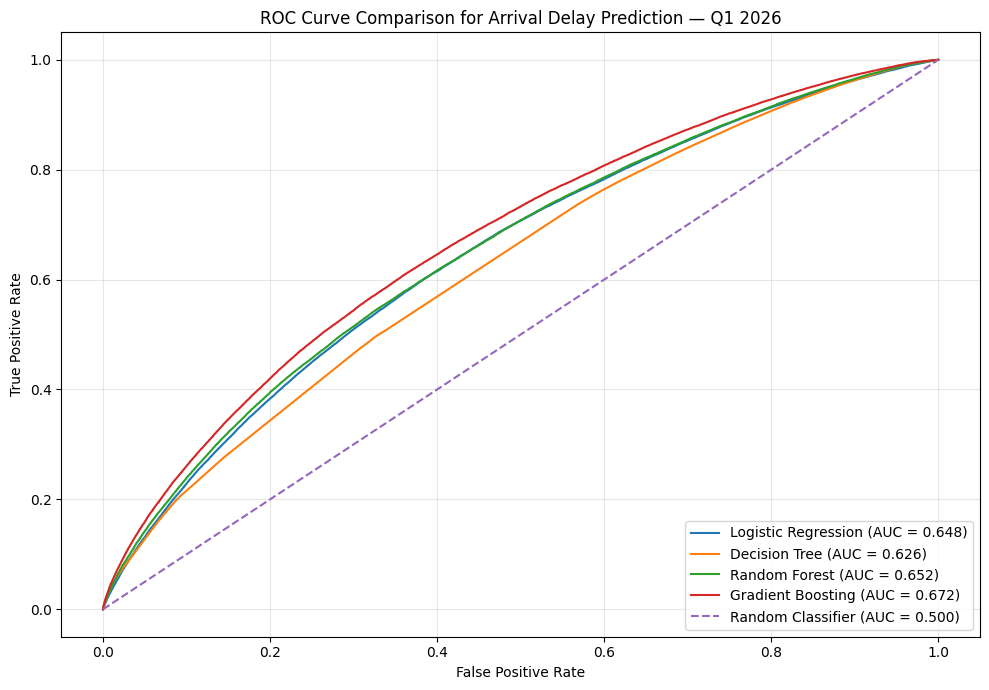

In [46]:
# ============================================================
# ROC CURVE COMPARISON — ALL MODELS
# Q1 2026 ARRIVAL DELAY PREDICTION
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curves
log_fpr, log_tpr, _ = roc_curve(y_test, log_probabilities)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probabilities)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probabilities)

# Calculate AUC values
log_roc_auc = auc(log_fpr, log_tpr)
tree_roc_auc = auc(tree_fpr, tree_tpr)
rf_roc_auc = auc(rf_fpr, rf_tpr)
gb_roc_auc = auc(gb_fpr, gb_tpr)

# Create plot
plt.figure(figsize=(10, 7))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_roc_auc:.3f})"
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Decision Tree (AUC = {tree_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC = {gb_roc_auc:.3f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison for Arrival Delay Prediction — Q1 2026"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

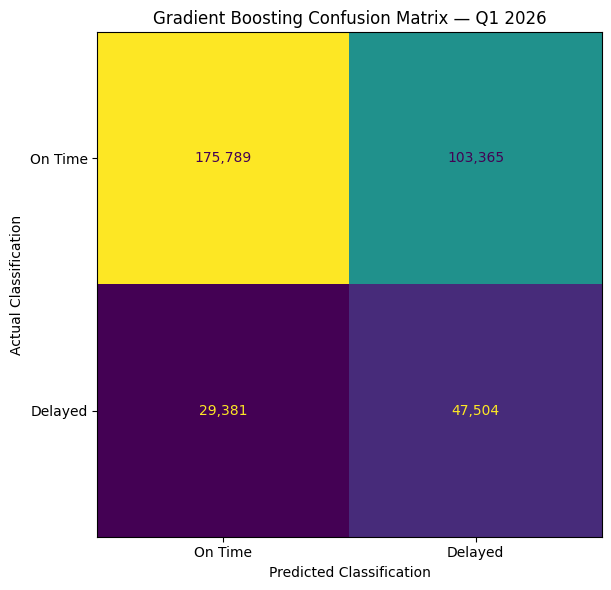

GRADIENT BOOSTING CLASSIFICATION RESULTS
Correctly predicted on-time flights: 175,789
On-time flights incorrectly flagged as delayed: 103,365
Delayed flights incorrectly predicted on time: 29,381
Correctly predicted delayed flights: 47,504

Total correct predictions: 223,293
Total incorrect predictions: 132,746


In [47]:
# ============================================================
# GRADIENT BOOSTING CONFUSION MATRIX
# Q1 2026 ARRIVAL DELAY PREDICTION
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate confusion matrix
gb_cm = confusion_matrix(y_test, gb_predictions)

# Create visualization
fig, ax = plt.subplots(figsize=(7, 6))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=gb_cm,
    display_labels=["On Time", "Delayed"]
)

display_cm.plot(
    ax=ax,
    values_format=",d",
    colorbar=False
)

plt.title(
    "Gradient Boosting Confusion Matrix — Q1 2026"
)

plt.xlabel("Predicted Classification")
plt.ylabel("Actual Classification")

plt.tight_layout()
plt.show()

# Print interpretation values
tn, fp, fn, tp = gb_cm.ravel()

print("GRADIENT BOOSTING CLASSIFICATION RESULTS")
print("=" * 55)

print(f"Correctly predicted on-time flights: {tn:,}")
print(f"On-time flights incorrectly flagged as delayed: {fp:,}")
print(f"Delayed flights incorrectly predicted on time: {fn:,}")
print(f"Correctly predicted delayed flights: {tp:,}")

print("\nTotal correct predictions:", f"{tn + tp:,}")
print("Total incorrect predictions:", f"{fp + fn:,}")

CALCULATING FEATURE IMPORTANCE

FEATURE IMPORTANCE — GRADIENT BOOSTING


,Feature,Importance,Std_Dev
0,DEP_HOUR,0.0800,0.0025
1,MKT_UNIQUE_CARRIER,0.0299,0.0017
2,DAY_OF_WEEK,0.0291,0.0006
3,ORIGIN,0.0254,0.0013
4,MONTH,0.0232,0.0009
5,DEST,0.0222,0.0011
6,DISTANCE,0.0125,0.0007


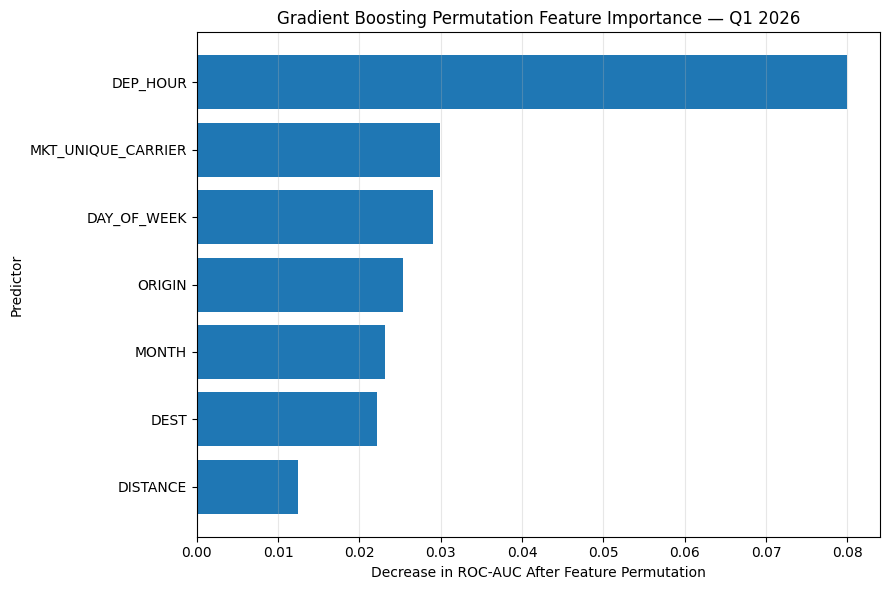

In [48]:
# ============================================================
# GRADIENT BOOSTING FEATURE IMPORTANCE
# Permutation Importance — Q1 2026
# ============================================================

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

print("CALCULATING FEATURE IMPORTANCE")
print("=" * 60)

# Use a sample to keep computation fast
sample_size = 30000

X_importance = X_test_gb.sample(
    n=sample_size,
    random_state=42
)

y_importance = y_test.loc[X_importance.index]

# Calculate permutation importance using ROC-AUC
importance_results = permutation_importance(
    gb_model,
    X_importance,
    y_importance,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Create results table
feature_importance = pd.DataFrame({
    "Feature": X_importance.columns,
    "Importance": importance_results.importances_mean,
    "Std_Dev": importance_results.importances_std
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\nFEATURE IMPORTANCE — GRADIENT BOOSTING")
print("=" * 60)

display(
    feature_importance.round(4)
)

# Plot
plot_importance = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance"]
)

plt.xlabel("Decrease in ROC-AUC After Feature Permutation")
plt.ylabel("Predictor")

plt.title(
    "Gradient Boosting Permutation Feature Importance — Q1 2026"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Model Interpretation

Permutation importance analysis showed that scheduled departure hour was the most influential predictor in the Gradient Boosting model. Its importance was substantially larger than that of any other feature, indicating that the time at which a flight is scheduled to depart plays an important role in delay risk. This finding is consistent with the exploratory analysis, which showed that early-morning flights had substantially lower delay rates than afternoon and evening flights.

Airline, day of week, origin airport, month, and destination airport also contributed meaningfully to prediction. These findings reinforce the earlier descriptive results showing variation in delay performance across carriers, airports, days, and months. Flight distance had the lowest permutation importance among the seven predictors, suggesting that route length alone was less informative than operational and temporal characteristics when predicting arrival delays.